In [26]:
# import all packages
import numpy as np
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd
# from plot_functions import plot_50states

### Read roadway lengths

In [27]:
# folder_path = r'D:\Work\Box Sync\Quantify Infrastructure\Streets_df\All states'
folder_path = r'D:\Work\Box Sync\Quantify Infrastructure\OSM_raodway _length\All states'

# Get a list of all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty DataFrame to store concatenated data
concatenated_df = pd.DataFrame()

# Loop through each CSV file and concatenate them
for file in csv_files:
    # print(file)
    file_path = os.path.join(folder_path, file)
    
    # Read the CSV file into a DataFrame
    df_state = pd.read_csv(file_path, index_col =0)
    # to check how many places are excluded
    # print(df_state.shape[0])
    # count = count + df_state.shape[0]
    df_state['GEOID'] = df_state['GEOID'].astype(str).str.rjust(7, '0')
    
    # Concatenate the DataFrame to the existing data
    concatenated_df = pd.concat([concatenated_df, df_state], ignore_index=True)
print(concatenated_df.shape)

# 13 missing places due to missing geometry
# Total no of places for 50 states in 2020
# 31249+13 = 31262

(31257, 74)


In [28]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
print(places_US.shape)

places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

print(places_50_states.shape)

(32188, 17)
(31262, 17)


<Axes: >

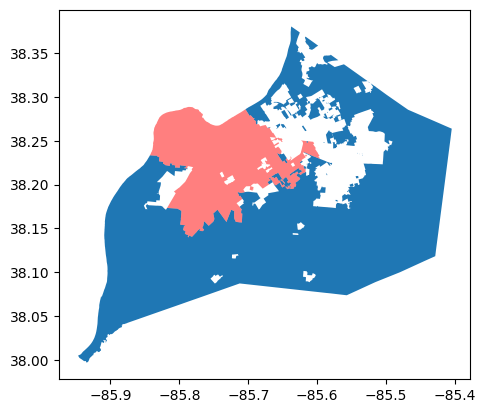

In [29]:
ax = places_50_states[places_50_states['GEOID'] == '2148006'].plot() # 	Louisville/Jefferson County metro government 
places_50_states[places_50_states['GEOID'] == '2148000'].plot(ax=ax, color='red', alpha = 0.5) # 	Louisville city

In [30]:
concatenated_df[['GEOID', 'NAMELSAD',  'secondary', 'tertiary', 'unclassified', 'residential', 'cl_tertiary', 'cl_unclassified', 'cl_residential', 'cl_service', 
                'lane_m_tertiary', 'lane_m_unclassified', 'lane_m_residential', 'lane_m_service', 'lane_m_living_street']]

,GEOID,NAMELSAD,secondary,tertiary,unclassified,residential,cl_tertiary,cl_unclassified,cl_residential,cl_service,lane_m_tertiary,lane_m_unclassified,lane_m_residential,lane_m_service,lane_m_living_street
0,0102260,Ardmore town,4515.602482,3414.774786,4679.351779,37801.086488,1707.387393,2339.675890,18935.832311,0.0,3414.774786,4679.351779,37801.086488,0.0,0.0
1,0151264,Mooresville town,0.000000,1221.009218,0.000000,4847.498766,665.526838,0.000000,2454.805855,0.0,1221.009218,0.000000,4847.498766,0.0,0.0
2,0171496,Somerville town,16702.050370,0.000000,0.000000,42007.387675,0.000000,0.000000,21003.693838,0.0,0.000000,0.000000,42007.387675,0.0,0.0
3,0176872,Trinity town,0.000000,24753.439644,3779.474886,64473.206717,12376.719822,1889.737443,32412.521614,0.0,24753.439644,3779.474886,65119.263280,0.0,0.0
4,0130880,Goshen town,0.000000,12662.955318,2292.404495,16229.565230,6331.477659,1146.202247,8114.782615,0.0,12662.955318,2292.404495,16229.565230,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31252,5682967,Westview Circle CDP,0.000000,4263.347727,10043.795432,0.000000,2131.673863,5021.897716,0.000000,0.0,4263.347727,10043.795432,0.000000,0.0,0.0
31253,5683100,Whiting CDP,905.820922,0.000000,3700.969039,10038.096588,0.000000,1850.484519,5019.048294,0.0,0.000000,3700.969039,10038.096588,0.0,0.0
31254,5683765,Wilson CDP,0.000000,16248.866529,12445.031137,101746.758794,8124.433264,6222.515569,50873.379397,0.0,16248.866529,12445.031137,101746.758794,0.0,0.0
31255,5684852,Woods Landing-Jelm CDP,11219.746664,0.402589,77.105373,37021.023978,0.201295,38.552687,18510.511989,0.0,0.402589,77.105373,37021.023978,0.0,0.0


In [31]:
# concatenated_df.dtypes

In [32]:
df = concatenated_df.copy()

In [33]:
# # NOT NEEDED ANYMORE
# # Convert link lengths from str of list elements to float 
# def str_to_float(df, column_name):
#     return df[column_name].str.replace("[","").str.replace("]","").astype(float)

# column_list = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential', 
#                'cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']


# for column in column_list:
#     df[column] = str_to_float(df, column)

In [34]:
# df.columns

In [35]:
# Calculate total roadway length and total centerline roadway length
roadway_columns = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential', 'service', 'living_street']
cl_roadway_columns = ['cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']
lane_m_roadway_columns = ['lane_m_motorway', 'lane_m_trunk', 'lane_m_primary','lane_m_secondary', 'lane_m_tertiary', 'lane_m_unclassified',
                          'lane_m_residential', 'lane_m_service', 'lane_m_track','lane_m_footway', 'lane_m_cycleway', 'lane_m_living_street']
cl_local_columns = ['cl_unclassified', 'cl_residential', 'cl_service'] # 'cl_secondary'
lane_m_local_columns =['lane_m_unclassified', 'lane_m_residential', 'lane_m_service','lane_m_living_street'] # 'lane_m_secondary', 'lane_m_track','lane_m_footway', 'lane_m_cycleway',
footway_columns = ['footway','n_residential','n_footway']

df['total_length'] = df[roadway_columns].sum(axis=1)
df['cl_all_classes'] = df[cl_roadway_columns].sum(axis=1)
df['lane_m_all_classes'] = df[lane_m_roadway_columns].sum(axis=1)
df['cl_local_length'] = df[cl_local_columns].sum(axis=1)
df['cl_total_length'] = df[lane_m_local_columns].sum(axis=1) 
df['walkway_length'] = df[footway_columns].sum(axis=1)

# df['road_area_m2'] = df['motorway'] * 13.6 + df['trunk'] * 9.6 + df['primary'] * 6.0 + df['secondary'] * 5.3 + df['tertiary'] * 4.9 +\
#       df['unclassified'] * 4.5 + df['residential'] * 4.5
df['road_lanearea_m2'] = df['lane_m_all_classes'] * 3.6

df['pct_cl_local'] = df['cl_local_length'] * 100 / df['cl_all_classes']
df['pct_local'] = df['cl_total_length'] * 100 / df['lane_m_all_classes']
df['pct_walkway'] = df['walkway_length']*100/df['cl_total_length'] # This value need to be checked since residential (auto) can have walkways too

In [36]:
print(f"Total cities with zero local roadways:==== {df[(df['cl_total_length']==0)].shape[0]}")
print(f"CDPs with zero local roadways:==== {df[(df['NAMELSAD'].str.contains('CDP')) & (df['cl_total_length']==0)].shape[0]}")
print(f"CDPs with local roadways:==== {df[(df['NAMELSAD'].str.contains('CDP')) & (df['cl_total_length']!=0)].shape[0]}")
print(f"Total non-zero local lane-meter available for {df[(df['cl_total_length']!=0)].shape[0]} cities")
# df[(df['NAMELSAD'].str.contains('CDP')) &(df['cl_total_length']!=0)]

Total cities with zero local roadways:==== 61
CDPs with zero local roadways:==== 50
CDPs with local roadways:==== 11837
Total non-zero local lane-meter available for 31196 cities


In [37]:
df[(df['NAMELSAD'].str.contains('CDP')) &(df['cl_total_length']!=0)][['GEOID', 'NAMELSAD', 'total_length', 'cl_all_classes', 'lane_m_all_classes', 'cl_total_length','pct_local']].sort_values(by=['pct_local']).round(2)

,GEOID,NAMELSAD,total_length,cl_all_classes,lane_m_all_classes,cl_total_length,pct_local
11744,2481925,Waterview CDP,3525.54,1762.77,3525.54,2.54,0.07
22564,4105700,Bellfountain CDP,8238.62,4119.31,8238.62,7.22,0.09
5722,1510900,Haliimaile CDP,12810.60,6405.30,12810.60,11.51,0.09
2975,0658422,Posey CDP,6248.86,3124.43,6248.86,12.16,0.19
17143,3470984,Stockton University CDP,15798.03,7938.37,15798.03,32.66,0.21
...,...,...,...,...,...,...,...
27851,4865049,San Carlos I CDP,5401.61,2700.81,5401.61,5401.61,100.00
2748,0641880,Littlerock CDP,6758.16,3379.08,6758.16,6758.16,100.00
25560,4648820,Pearl Creek Colony CDP,12029.21,6014.61,12029.21,12029.21,100.00
30088,5416972,Colcord CDP,5378.40,2689.20,5378.40,5378.40,100.00


In [38]:
print(f"Total centerline length of local roadways: {df['cl_local_length'].sum().round(2)}")
print(f"Total lane meter length of local roadways: {df['cl_total_length'].sum().round(2)}")

Total centerline length of local roadways: 1624750936.58
Total lane meter length of local roadways: 3254473174.95


In [39]:
# NaNs values in roadway length dataframe
df.isna().sum().sum()

68

### Import population and attributes data from depopulation study

In [40]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi','median_income']], on = 'GEOID')
print(df_population.shape, df_attributes.shape, df_pop_attr.shape)


(31617, 58) (31908, 33) (31616, 62)


In [41]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994929
ssp22030        271.282551
ssp22040        289.394587
ssp22050        305.168766
ssp22060        320.539073
ssp22070        334.443119
ssp22080        344.689135
ssp22090        350.775132
ssp22100        353.489903
dtype: float64

### Merge roads with population

In [42]:
roads_with_pop_all = df.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'ALAND', 'label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi','median_income',
                                       'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                       'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                                                   'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060',
                                                   'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on = 'GEOID', how='left')
print(roads_with_pop_all.shape)

print(roads_with_pop_all[roads_with_pop_all['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']])
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

print('Total population in millions for 50 states: ===')
print(roads_with_pop_all[['CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000)

roads_with_pop_all['percentchangeinpop'] = np.abs((roads_with_pop_all['ssp42020'] - roads_with_pop_all['CensusPop_20'])/roads_with_pop_all['CensusPop_20'])
# cities that have their 2020 census population with 1% variation of the projected ssp22020 population are included in the analysis
roads_with_pop = roads_with_pop_all[(roads_with_pop_all['percentchangeinpop'] <=.01)]
print(roads_with_pop.shape)
# roads_with_pop_all[roads_with_pop_all['percentchangeinpop'] > 0.01][['GEOID','NAMELSAD', 'CensusPop_20', 'ssp22020',]].sort_values(by='ssp22020')

(31257, 120)
         GEOID                                           NAMELSAD  \
10248  2148006  Louisville/Jefferson County metro government (...   
10408  2148000                                    Louisville city   

       CensusPop_20     ssp22020     ssp22030     ssp22040     ssp22050  
10248      386884.0  389068.4372  424417.2341  456660.9352  485264.1312  
10408           NaN          NaN          NaN          NaN          NaN  
Total population in millions for 50 states: ===
CensusPop_20    248.780912
ssp22020        250.288598
ssp22030        270.512914
ssp22040        288.565991
ssp22050        304.283774
ssp22060        319.591951
ssp22070        333.445045
ssp22080        343.643353
ssp22090        349.692887
ssp22100        352.379465
dtype: float64
(30578, 121)


### Read redefined urban rural classes

In [43]:
df_urban_rural_conn = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\output_city_type.csv')
df_urban_rural_conn = df_urban_rural_conn[['GEOID','citytype_at_2030',  'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060',
                                           'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100']]
                                           
df_urban_rural_conn['GEOID'] = df_urban_rural_conn['GEOID'].astype(str).str.rjust(7,'0')
# This step excludes 36 CDPs that were newly added and therefore do not have sufficient data for urban rural classification
roads_with_pop = roads_with_pop.merge(df_urban_rural_conn, on = 'GEOID',)

In [44]:
roads_with_pop.shape

(30541, 129)

In [45]:
roads_with_pop['road_density_m-sqm'] = roads_with_pop['cl_total_length'] /roads_with_pop['ALAND']
roads_with_pop['road_density'] = roads_with_pop['road_lanearea_m2'] * 100/roads_with_pop['ALAND']

In [46]:
roads_with_pop[['road_density_m-sqm', 'pct_local']].describe()

,road_density_m-sqm,pct_local
count,30541.000000,30537.000000
mean,0.009597,68.211673
std,0.006330,16.046799
min,0.000000,0.000000
25%,0.004858,59.075089
50%,0.008416,69.814237
75%,0.012881,79.184195
max,0.072936,100.000000


In [48]:
roads_with_pop.groupby(['city type','REGION'])[['pct_local', 'pct_cl_local']].median().round(2)

pct_local  pct_cl_local
city type REGION                            
periurban Midwest        71.32         73.02
          Northeast      69.81         71.14
          South          70.11         72.05
          West           69.44         71.66
rural     Midwest        74.67         74.82
          Northeast      64.87         64.97
          South          68.61         69.54
          West           70.77         71.33
suburban  Midwest        66.34         69.98
          Northeast      69.11         71.39
          South          67.06         70.71
          West           64.31         68.12
urban     Midwest        57.00         67.90
          Northeast      64.05         67.10
          South          58.59         64.19
          West           51.13         58.70

In [49]:
# Exclude total zero roadways
print(f"Total cities with nonzero local roadway lane meter {roads_with_pop[roads_with_pop['cl_total_length']!=0].shape[0]}")

Total cities with nonzero local roadway lane meter 30502


### Model comparision Pruned Nonpruned F_test

In [50]:
roads_with_pop['per_cap_mass_at_2020'] =  roads_with_pop['cl_total_length'] / roads_with_pop['CensusPop_20']

stocks_with_pop = roads_with_pop[roads_with_pop['CensusPop_20'] != 0]
stocks_with_pop = roads_with_pop[roads_with_pop['per_cap_mass_at_2020'] != 0]
# stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

infra_col ='cl_total_length'
pop_col = 'CensusPop_20'
df = stocks_with_pop.copy()

### ============== PRUNING ============== ###
# Set the threshold to the 90th percentile
threshold_u = df[infra_col].quantile(0.9)
threshold_l = df[infra_col].quantile(0.1)
# Filter the DataFrame to include only points in the top 10%
df_pruned = df[df[infra_col] < threshold_u]
df_pruned = df_pruned[df_pruned[infra_col] > threshold_l]
print(df_pruned.shape)

y = np.log(df[infra_col].astype(float))
x = np.log(df[pop_col].astype(float))

y_pruned = np.log(df_pruned[infra_col].astype(float))
x_pruned = np.log(df_pruned[pop_col].astype(float)) 

m01 = sm.ols("y ~ x", data={"y": y, "x": x}).fit()
print(m01.params)
print("R-squared value" , m01.rsquared)
m02 = sm.ols("y_pruned ~ x_pruned", data={"y_pruned": y_pruned, "x_pruned": x_pruned}).fit()
anova_results= anova_lm(m01, m02)
print(m02.params)
print("R-squared value" , m02.rsquared)
print(anova_results)
print('\n')

if anova_results['Pr(>F)'][1] < 0.005:
    print(f"Since {anova_results['Pr(>F)'][1]} < 0.005, difference is significant")
    print("Built pruned model")


(30502, 132)
(24400, 132)
Intercept    5.965883
x            0.643768
dtype: float64
R-squared value 0.7600487966837176
Intercept    7.060852
x_pruned     0.492174
dtype: float64
R-squared value 0.6373629582944739
   df_resid           ssr  df_diff      ss_diff         F  Pr(>F)
0   30500.0  13400.299466      0.0          NaN       NaN     NaN
1   24398.0   6822.124549   6102.0  6578.174917  3.855385     0.0


Since 0.0 < 0.005, difference is significant
Built pruned model


In [51]:
pd.set_option('mode.chained_assignment', None) # To stop SettingWithCopy warning
list_of_city_types = ['urban', 'suburban', 'periurban', 'rural']

In [52]:
print('Total NaNs in population and roadway length:===')
print(roads_with_pop[['CensusPop_20', 'ssp22040', 'cl_total_length']].isna().sum())
print("Places with no roadway:===", roads_with_pop[roads_with_pop['cl_total_length'] == 0].shape[0])
print("Places with zero population in census 2020:===", roads_with_pop[roads_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", roads_with_pop[roads_with_pop['ssp22040'].isnull()].shape[0])
print(roads_with_pop.shape)

Total NaNs in population and roadway length:===
CensusPop_20       0
ssp22040           0
cl_total_length    0
dtype: int64
Places with no roadway:=== 39
Places with zero population in census 2020:=== 0
Places with no available population forecast:=== 0
(30541, 132)


In [53]:
roads_clean = roads_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'total_length', 'cl_total_length']).reset_index(drop=True)
print(roads_clean.shape)
roads_clean = roads_clean[roads_clean['cl_total_length']!=0]
print(roads_clean.shape)
current_roadway_column = 'cl_total_length' # 'road_area_m2' # 

roads_clean['per_cap_mass_at_2020'] = roads_clean[current_roadway_column] / roads_clean['CensusPop_20'].round(0)
print("Shape of the clean dataset with nonzero values:==")
print(roads_clean.shape)
print(roads_clean[(roads_clean['per_cap_mass_at_2020'] > 10000) | (roads_clean['total_length'] < 500)][['GEOID','NAMELSAD','CensusPop_20','total_length', 'cl_total_length','per_cap_mass_at_2020']])
# roads_clean = roads_clean.merge(df_urban_rural_conn, on ='GEOID')
roads_clean = roads_clean[(roads_clean['per_cap_mass_at_2020'] <= 10000) & (roads_clean['total_length'] >= 500)]
print("Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==")
print(roads_clean.shape)

(30541, 132)
(30502, 132)
Shape of the clean dataset with nonzero values:==
(30502, 132)
         GEOID              NAMELSAD  CensusPop_20   total_length  \
686    0401170        Alamo Lake CDP           4.0  120493.451000   
4057   1205150   Belleair Shore town          73.0     172.774243   
15221  3063266  Riverview Colony CDP         100.0      15.341483   
17646  3664881      Saltaire village         113.0       7.194151   

       cl_total_length  per_cap_mass_at_2020  
686      100278.693928          25069.673482  
4057        149.044847              2.041710  
15221        15.341483              0.153415  
17646         7.194151              0.063665  
Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==
(30498, 132)


In [62]:
roads_clean.groupby(['city type','REGION'])[['pct_local', 'pct_cl_local','per_cap_mass_at_2020']].median().sort_values(['city type','pct_cl_local']).round(2)

pct_local  pct_cl_local  per_cap_mass_at_2020
city type REGION                                                  
periurban Northeast      69.80         71.13                 15.83
          West           69.45         71.69                 16.65
          South          70.12         72.05                 22.52
          Midwest        71.32         73.02                 19.88
rural     Northeast      64.97         65.11                 27.11
          South          68.66         69.55                 50.25
          West           70.81         71.38                 58.81
          Midwest        74.69         74.86                 43.28
suburban  West           64.34         68.12                 12.75
          Midwest        66.34         69.98                 15.61
          South          67.06         70.71                 18.20
          Northeast      69.13         71.39                 13.17
urban     West           51.13         58.70                  4.25
          South          58.59         64.19                  5.67
          Northeast      64.05         67.10                  4.73
          Midwest        57.00         67.90                  5.69

In [97]:
roads_with_pop.shape, df.shape, places_US.shape

((30541, 131), (30502, 131), (32188, 17))

In [93]:
31262-30498

764

In [27]:
# ''''
# Notes (Old for centerline):
# 1. Roadway lengths are measured in meters 
# 2. Centrerline total has been used for scale fitting and projecting. Lengths were checked with google maps, DOT values for some cities and 
# centerline values seemed more reasonable then total length
# roads_clean[roads_clean['NAMELSAD'].str.startswith('New York')][['GEOID', 'NAMELSAD', 'total_length', 'cl_total_length',]]
# 3. Cities with less than 1 km total roadway and over 10 km/person roadways were excluded from modeling
# that inculdes three cities, Saltaire village (NY), Riverview Colony CDP (Montana), and Alamo Lake CDP (AZ)

# '''

In [28]:
roads_clean[['GEOID', 'NAMELSAD','CensusPop_20','weighted_HU_density_sqmi','cl_total_length', 'per_cap_mass_at_2020']].sort_values(by=['per_cap_mass_at_2020'])

,GEOID,NAMELSAD,CensusPop_20,weighted_HU_density_sqmi,cl_total_length,per_cap_mass_at_2020
5636,1510900,Haliimaile CDP,1074.0,200.871680,1.151465e+01,0.010721
3857,0966086,Sacred Heart University CDP,1446.0,685.696172,1.592007e+01,0.011010
16717,3470984,Stockton University CDP,2428.0,3.567564,3.266290e+01,0.013453
2748,0645806,Marina del Rey CDP,11373.0,7530.902111,3.414851e+02,0.030026
2975,0663218,Rowland Heights CDP,48231.0,2390.428106,3.711404e+03,0.076951
...,...,...,...,...,...,...
23440,4226812,Fort Indiantown Gap CDP,68.0,32.849235,2.702329e+05,3974.013093
2641,0637512,Johnsville CDP,22.0,18.113667,1.043754e+05,4744.337092
15191,3053725,Niarada CDP,28.0,1.752265,1.689072e+05,6032.399989
19508,3811580,Calio city,8.0,0.788188,5.885333e+04,7356.666596


In [29]:
roads_clean.groupby('city type')[['cl_total_length', 'per_cap_mass_at_2020']].describe().round(2)

cl_total_length                                                      \
                    count       mean         std     min       25%        50%   
city type                                                                       
periurban          5691.0  146368.74   219403.61  270.44  38413.65   88052.78   
rural             17612.0   30181.99    43699.97    7.22  10575.86   20026.88   
suburban           6883.0  242358.43   569149.49   15.92  41041.57  101128.67   
urban               312.0  679355.69  1759411.79  341.49  49907.16  164274.19   

                                  per_cap_mass_at_2020                       \
                 75%          max                count   mean     std   min   
city type                                                                     
periurban  170337.65   4651712.94               5691.0  24.28   27.79  0.08   
rural       37418.71   3353142.13              17612.0  75.74  155.46  0.01   
suburban   242301.25  13692538.60               6883.0  18.86   20.05  0.01   
urban      500210.95  15978835.89                312.0   5.50    4.47  0.03   

                                         
             25%    50%    75%      max  
city type                                
periurban  13.10  19.30  28.45  1082.54  
rural      29.56  45.52  77.67  8178.40  
suburban   10.89  15.29  22.28  1126.44  
urban       3.36   4.70   6.78    61.12

In [30]:
roads_clean['city_type_order'] = roads_clean['city type'].map({'urban': 1, 'suburban': 2, 'periurban': 3, 'rural': 4, 'not enough data': 5})
roads_clean['REGION_order'] = roads_clean['REGION'].map({'Northeast': 1, 'Midwest': 2, 'West': 3, 'South': 4})

In [31]:
roads_clean[roads_clean['per_cap_mass_at_2020']>1000][['GEOID', 'NAMELSAD', 'city type', 'REGION', 'ALAND', 'CensusPop_20','per_cap_mass_at_2020']].sort_values('per_cap_mass_at_2020').shape

(45, 7)

In [32]:
roads_clean.groupby(['city type', 'REGION'])['per_cap_mass_at_2020'].describe().round(2)

count    mean     std   min    25%    50%     75%  \
city type REGION                                                          
periurban Midwest    1261.0   24.94   24.97  3.39  15.05  19.88   27.68   
          Northeast  1098.0   19.28   14.04  1.98  11.66  15.83   22.71   
          South      2120.0   26.57   24.57  3.41  14.68  22.52   31.84   
          West       1212.0   24.13   41.39  0.08   9.82  16.65   27.99   
rural     Midwest    6916.0   69.94  161.48  0.08  28.95  43.28   72.01   
          Northeast  1750.0   37.76  102.06  0.01  18.44  27.11   40.18   
          South      5796.0   72.83   88.60  1.91  34.20  50.25   81.00   
          West       3150.0  114.94  235.02  0.01  33.14  58.81  115.54   
suburban  Midwest    1626.0   18.79   17.66  1.29  11.77  15.61   21.05   
          Northeast  1780.0   15.74   10.04  0.01   9.88  13.17   18.36   
          South      2372.0   21.77   26.52  1.97  12.77  18.20   26.21   
          West       1105.0   17.74   18.39  0.29   8.80  12.75   20.40   
urban     Midwest      23.0    5.79    2.37  2.04   3.69   5.69    7.56   
          Northeast   133.0    5.45    5.86  0.53   2.94   4.73    6.40   
          South        78.0    6.49    3.68  0.56   4.04   5.67    8.87   
          West         78.0    4.50    2.16  0.03   3.20   4.25    5.61   

                         max  
city type REGION              
periurban Midwest     576.58  
          Northeast   202.31  
          South       597.36  
          West       1082.54  
rural     Midwest    8178.40  
          Northeast  3974.01  
          South      3195.53  
          West       6032.40  
suburban  Midwest     404.57  
          Northeast   103.30  
          South      1126.44  
          West        255.78  
urban     Midwest      10.07  
          Northeast    61.12  
          South        20.17  
          West          9.68

In [33]:
roads_clean.groupby(['city_type_order', 'REGION_order'])[['per_cap_mass_at_2020']].quantile([0.5]).T.round(2)

city_type_order          1                        2                      \
REGION_order             1     2     3     4      1      2      3     4   
                       0.5   0.5   0.5   0.5    0.5    0.5    0.5   0.5   
per_cap_mass_at_2020  4.73  5.69  4.25  5.67  13.17  15.61  12.75  18.2   

city_type_order           3                           4                       
REGION_order              1      2      3      4      1      2      3      4  
                        0.5    0.5    0.5    0.5    0.5    0.5    0.5    0.5  
per_cap_mass_at_2020  15.83  19.88  16.65  22.52  27.11  43.28  58.81  50.25

In [34]:
# roads_clean[['city_type_order', 'REGION_order']]

In [45]:
roads_clean.groupby('REGION')[['lane_m_motorway', 'lane_m_trunk', 'lane_m_primary', 'lane_m_secondary', 'lane_m_tertiary',
       'lane_m_unclassified', 'lane_m_residential', 'lane_m_service',
       'lane_m_living_street']].sum().sum(axis=1)

REGION
Midwest      1.170076e+09
Northeast    5.117290e+08
South        2.142123e+09
West         1.237886e+09
dtype: float64

In [58]:
roads_clean['pct_local_lane-m'] = roads_clean['cl_total_length'] / roads_clean[['lane_m_motorway', 'lane_m_trunk', 'lane_m_primary', 'lane_m_secondary', 'lane_m_tertiary',
       'lane_m_unclassified', 'lane_m_residential', 'lane_m_service', 'lane_m_living_street']].sum(axis=1)

In [60]:
roads_clean.groupby('REGION')['pct_local_lane-m'].describe()

,count,mean,std,min,25%,50%,75%,max
REGION,,,,,,,,
Midwest,9826.0,0.711869,0.148828,0.004592,0.625410,0.728956,0.814751,1.0
Northeast,4761.0,0.661209,0.156492,0.002068,0.573673,0.679436,0.767762,1.0
South,10366.0,0.673114,0.157048,0.016444,0.580960,0.684890,0.777606,1.0
West,5545.0,0.668894,0.173451,0.000876,0.567975,0.684773,0.791281,1.0


In [81]:
roads_clean[~roads_clean['NAMELSAD'].str.contains('CDP')].sort_values('pct_local_lane-m')[['GEOID', 'NAMELSAD','CensusPop_20','cl_total_length','pct_local_lane-m', 'REGION', 'city type']].head(12)

,GEOID,NAMELSAD,CensusPop_20,cl_total_length,pct_local_lane-m,REGION,city type
22484,4210240,Burlington borough,144.0,115.702876,0.015691,Northeast,rural
4093,1275625,Weeki Wachee city,16.0,270.441690,0.016444,South,periurban
12852,2742092,Miesville city,138.0,431.742629,0.043990,Midwest,rural
19853,3988070,Zanesfield village,194.0,232.063708,0.050427,Midwest,rural
5082,1351968,Mitchell town,153.0,914.583874,0.057618,South,rural
3921,1033250,Hartly town,73.0,188.727150,0.061030,South,rural
10485,2252565,Mound village,12.0,1477.792082,0.068294,South,rural
14191,2978928,West Plains city,12184.0,15752.210042,0.070517,Midwest,suburban
17660,3629872,Grand View-on-Hudson village,246.0,543.862765,0.072316,Northeast,rural
20595,3931542,Graysville village,70.0,814.747840,0.087029,Midwest,rural


In [82]:
roads_clean[~roads_clean['NAMELSAD'].str.contains('CDP')]['pct_local_lane-m'].describe()

count    19060.000000
mean         0.694726
std          0.141873
min          0.015691
25%          0.608987
50%          0.708100
75%          0.793814
max          1.000000
Name: pct_local_lane-m, dtype: float64

In [83]:
roads_clean[roads_clean['NAMELSAD'].str.contains('CDP')]['pct_local_lane-m'].describe()

count    11438.000000
mean         0.663392
std          0.181933
min          0.000876
25%          0.555442
50%          0.680241
75%          0.788819
max          1.000000
Name: pct_local_lane-m, dtype: float64

In [46]:
roads_clean.groupby('REGION')['cl_total_length'].sum()

REGION
Midwest      7.696902e+08
Northeast    3.336014e+08
South        1.368431e+09
West         7.729387e+08
Name: cl_total_length, dtype: float64

In [48]:
roads_clean.shape

(30498, 133)

In [50]:
3244661792.5350504/5061813781.647831, 3.336014e+08/5.117290e+08, 7.696902e+08/1.170076e+09, 7.729387e+08/1.237886e+09, 1.368431e+09/2.142123e+09, 

(0.6410077360607245,
 0.6519102884534588,
 0.6578121421172641,
 0.6244021662737925,
 0.6388199930629567)

In [ ]:
print(f"for Northeast percent non local roadway {}")

In [53]:
1.237886e+09*(1-.62)/1000

470396.68

In [35]:
roads_clean.columns[10:30]

Index(['track', 'footway', 'cycleway', 'living_street', 'cl_motorway',
       'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary',
       'cl_unclassified', 'cl_residential', 'cl_service', 'cl_track',
       'cl_footway', 'cl_cycleway', 'cl_living_street', 'lane_m_motorway',
       'lane_m_trunk', 'lane_m_primary', 'lane_m_secondary'],
      dtype='object')

In [36]:
roads_clean[roads_clean['city type'] == 'urban'][['GEOID', 'NAMELSAD','cl_unclassified', 'cl_residential', 'cl_service','per_cap_mass_at_2020']].sort_values('per_cap_mass_at_2020')

,GEOID,NAMELSAD,cl_unclassified,cl_residential,cl_service,per_cap_mass_at_2020
2748,0645806,Marina del Rey CDP,0.000000,175.494179,0.00000,0.030026
2144,0601150,Alondra Park CDP,0.000000,787.160850,0.00000,0.183723
2403,0620802,East Los Angeles CDP,300.923633,29672.282169,0.00000,0.501030
16161,3432250,Hoboken city,5018.185826,22704.574045,287.01244,0.532193
11297,2430800,Friendship Heights Village CDP,0.000000,1662.584353,0.00000,0.560880
...,...,...,...,...,...,...
4125,1264725,Sea Ranch Lakes village,0.000000,5072.484778,0.00000,17.917288
16229,3466480,Seaside Park borough,0.000000,16786.261279,0.00000,18.952195
4385,1243083,Marco Island city,4129.681640,157106.593878,0.00000,20.169389
16123,3454360,Ocean City city,49.676633,109595.080331,0.00000,28.822668


In [37]:
# grouped = roads_clean[roads_clean['city type'] != 'rural'].groupby(['city_type_order', 'REGION_order'])['per_cap_mass_at_2020'].describe().T
# grouped.boxplot(showfliers=False ) #,vert =False)

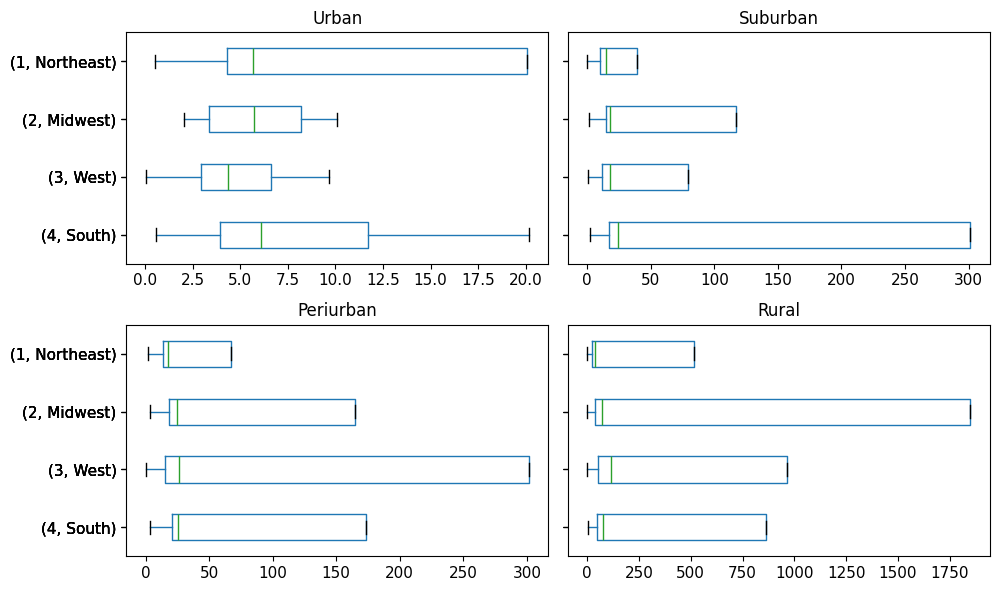

In [38]:
data = roads_clean
# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
data[data['city type'] == 'urban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
axs[0, 0].invert_yaxis()
# # Boxplot for Value1 and Value3 in the second subplot
data[data['city type'] == 'suburban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
data[data['city type'] == 'periurban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
data[data['city type'] == 'rural'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    # ax.axis("off")
    ax.grid(False)

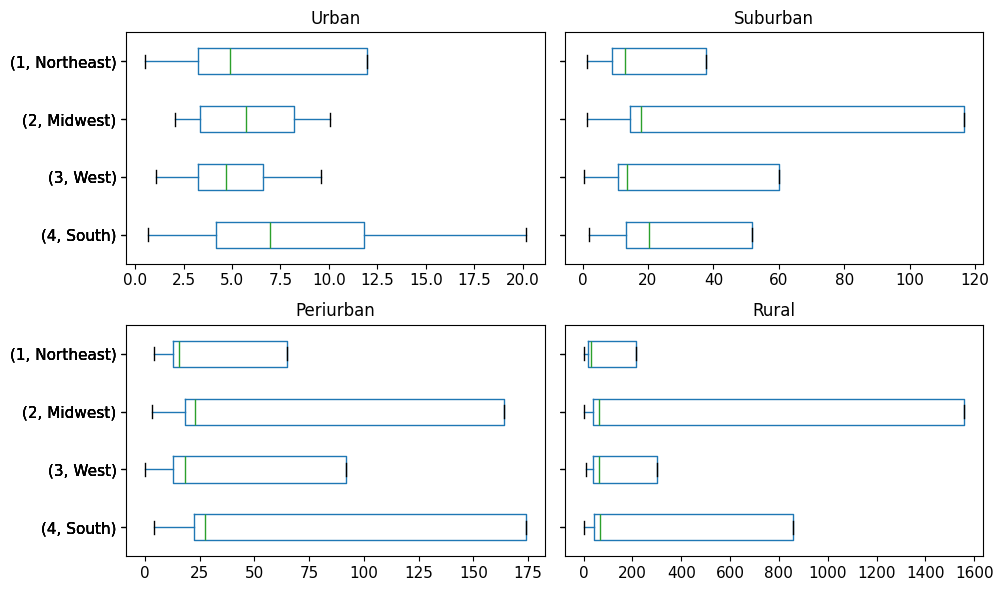

In [39]:
data = roads_clean
data = data[~data['NAMELSAD'].str.contains('CDP')]
# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
data[data['city type'] == 'urban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
axs[0, 0].invert_yaxis()
# # Boxplot for Value1 and Value3 in the second subplot
data[data['city type'] == 'suburban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
data[data['city type'] == 'periurban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
data[data['city type'] == 'rural'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    # ax.axis("off")
    ax.grid(False)
    

In [40]:
# data[(data['city type']=='urban') & (data['REGION']=='South')][['GEOID', 'NAMELSAD', 'road_density_mi-sqmi','road_density', 'per_cap_mass_at_2020']].sort_values('per_cap_mass_at_2020')

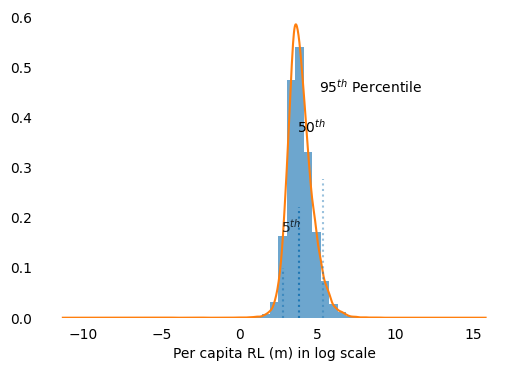

In [41]:
avocado = np.log(roads_clean[roads_clean['city type'] == 'rural']['per_cap_mass_at_2020'])
# sns.histplot(np.log(data['per_cap_mass_at_2020']), alpha = 0.8, color= 'grey', linewidth=0.2)
# citytype_name = ['urban', 'suburban', 'periurban', 'rural']

fig, ax = plt.subplots(figsize = (6,4))

# Plot
    # Plot histogram
avocado.plot(kind = "hist", density = True, alpha = 0.65, bins = 25) # change density to true, because KDE uses density
    # Plot KDE
avocado.plot(kind = "kde")

# Quantile lines
quant_5, quant_25, quant_50, quant_75, quant_95 = avocado.quantile(0.05), avocado.quantile(0.25), avocado.quantile(0.5), avocado.quantile(0.75), avocado.quantile(0.95)
quants = [[quant_5, 0.6, 0.16], [quant_50, 1, 0.36],  [quant_95, 0.45, 0.45]] # [quant_25, 0.8, 0.26], [quant_75, 0.8, 0.46], 
for i in quants:
    ax.axvline(i[0], alpha = i[1], ymax = i[2], linestyle = ":")

# X
ax.set_xlabel("Per capita RL (m) in log scale")
    # Limit x range to 0-4
x_start, x_end = 0, 15
# ax.set_xlim(x_start, x_end)

# Y
# ax.set_ylim(0, 1)
# ax.set_yticklabels([])
ax.set_ylabel("")

# Annotations
ax.text(quant_5-.1, 0.17, "5$^{th}$", size = 10, alpha = 0.8)
# ax.text(quant_25-.13, 0.27, "25th", size = 11, alpha = 0.8)
ax.text(quant_50-.13, 0.37, "50$^{th}$", size = 10, alpha = 1)
# ax.text(quant_75-.13, 0.47, "75th", size = 11, alpha = 0.8)
ax.text(quant_95-.25, 0.45, "95$^{th}$ Percentile", size = 10, alpha =1)

# Overall
ax.grid(False)
# ax.set_title("Avocado Prices in U.S. Markets", size = 17, pad = 10)

    # Remove ticks and spines
ax.tick_params(left = False, bottom = False)
for ax, spine in ax.spines.items():
    spine.set_visible(False)
    
plt.show()

In [42]:
np.exp(-10), np.exp(-5), np.exp(5), np.exp(15)

(4.5399929762484854e-05,
 0.006737946999085467,
 148.4131591025766,
 3269017.3724721107)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                 3.566e+04
Date:                Sun, 15 Sep 2024   Prob (F-statistic):               0.00
Time:                        15:46:33   Log-Likelihood:                -5489.6
No. Observations:                6883   AIC:                         1.098e+04
Df Residuals:                    6881   BIC:                         1.100e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2349      0.039    108.543      0.0

([4.158396718366816, 4.311362428270869],
 [0.8216733389294043, 0.838912856204172],
 Intercept    4.234880
 x            0.830293
 dtype: float64)

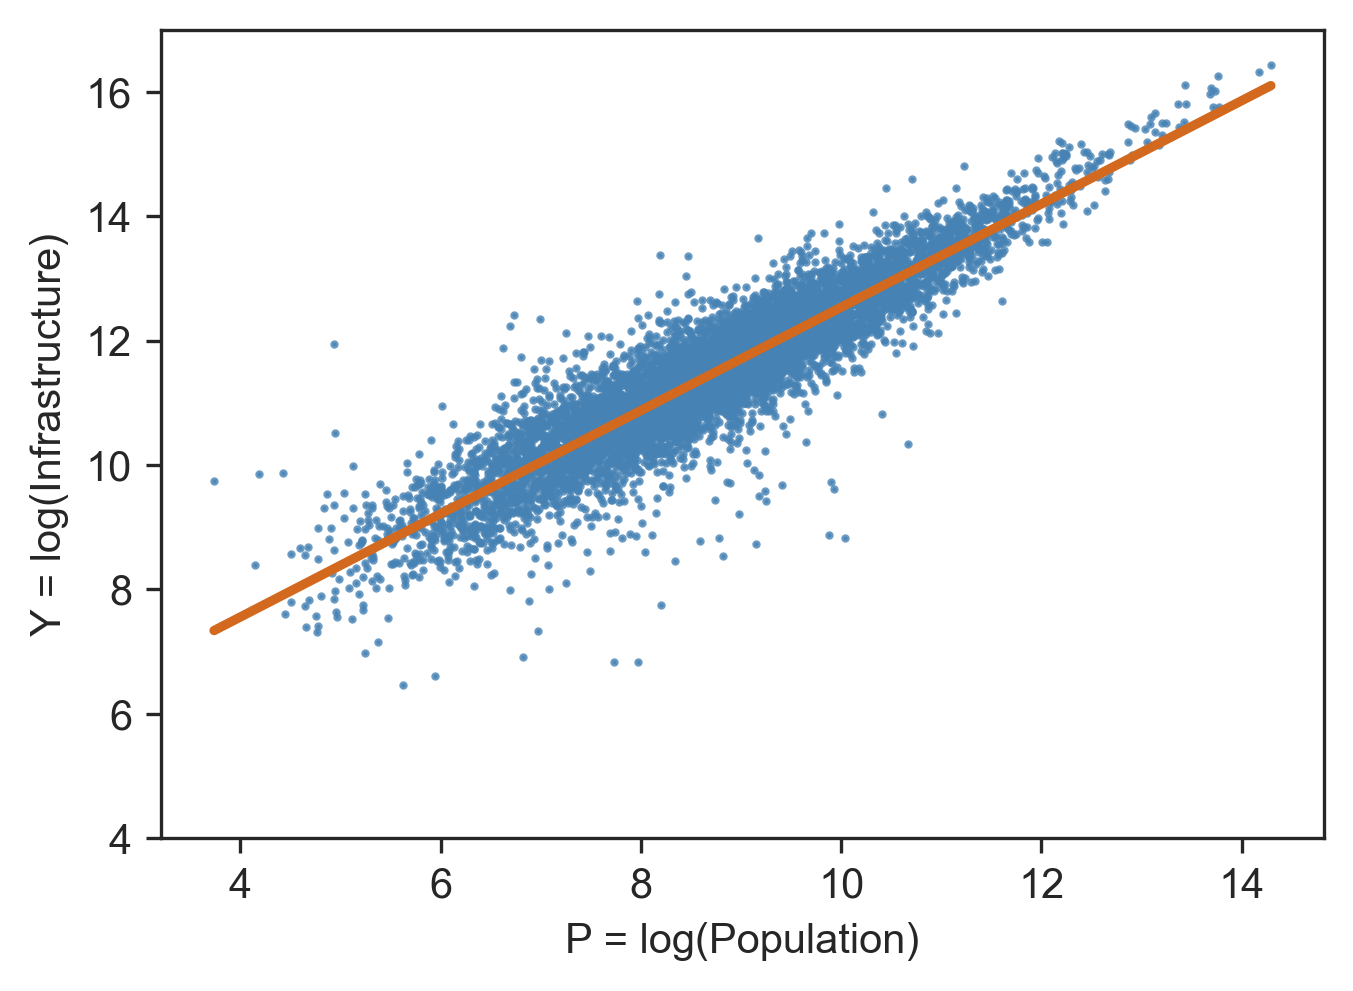

In [43]:
def find_example_scale_parameters(df, infra_col, pop_col):
    '''
    Fit data to liner regression
    Columns are transformed to log scale before plotting
    - infra_col: total infrastructure length/ area/volume for a city
    - pop_col: population data for a city
    - returns model parameters as intercepts, beta, model_params
    '''
    df.loc[:,'log_pop_col'] = np.log(df[pop_col].astype(float))
    df.loc[:, 'log_infra_col'] = np.log(df[infra_col].astype(float))

    # fig = px.scatter(df, x='log_pop_col', y='log_infra_col', hover_data=['GEOID', 'NAMELSAD'],
    #                 width=800, height=800) 
    # fig.show()
    sns.set_style('ticks')
    fig, ax = plt.subplots(dpi=300)
    # the size of A4 paper
    fig.set_size_inches(5,3.5)
    # Check plot how the log-log plot looks?
    sns.regplot(ax=ax,x='log_pop_col', y='log_infra_col', data=df, line_kws={"color": "chocolate"}, color="steelblue",
                y_jitter=.03, ci =None, scatter_kws={"s": 1})
    ax.set(xlabel='P = log(Population)', ylabel = 'Y = log(Infrastructure)')
    ax.set_ylim(4,17)
    # fig = ax.get_figure()
    # plt.savefig(r'D:\Work\Box Sync\Applications\Senseble lab MIT\Interview docs\scalingRelation.png', transparent=True,  bbox_inches='tight')

    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    print(model.summary())
    print(model.params)
    print("R-squared value" , model.rsquared)
    print('====================================')
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
    beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
    model_params = model.params
    return intercepts, beta, model_params

find_example_scale_parameters(roads_clean[roads_clean['city type'] == 'suburban'],  'cl_total_length', 'CensusPop_20')

In [44]:
roads_clean.columns

Index(['GEOID', 'NAMELSAD', 'motorway', 'trunk', 'primary', 'secondary',
       'tertiary', 'unclassified', 'residential', 'service',
       ...
       'citytype_at_2060', 'citytype_at_2070', 'citytype_at_2080',
       'citytype_at_2090', 'citytype_at_2100', 'road_density_m-sqm',
       'road_density', 'per_cap_mass_at_2020', 'city_type_order',
       'REGION_order'],
      dtype='object', length=133)

### Run loops 

### for 2030

(30498, 27)
Initial dataframe:====
(30498, 27)
Shape of the dataframe for urban:====
(312, 28)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 28)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     1438.
Date:                Sun, 15 Sep 2024   Prob (F-statistic):          7.12e-112
Time:                        15:46:34   Log-Likelihood:                -242.50
No. Observations:                 280   AIC:                             489.0
Df Residuals:                     278   BIC:                             496.3
Df Model:                           1                                         
Covariance Type:      

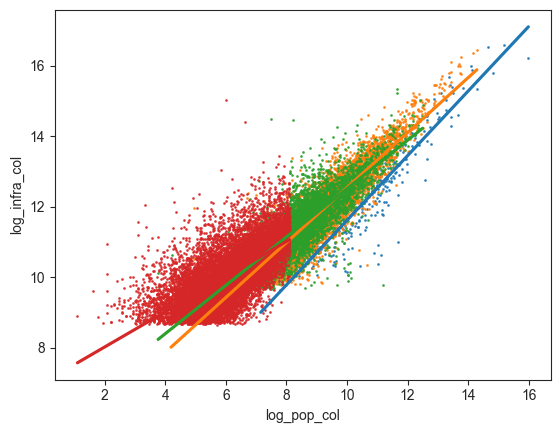

In [45]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'D:\Work\Box Sync\Quantify Infrastructure\Scripts\scenarios')
from functions.functions_scaling import find_scale_parameters, find_next_stock, process_stock_at_t


current_stock_col = 'cl_total_length'
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030

roads_clean['stock_at_t0'] = roads_clean['cl_total_length']
df_for_analysis = roads_clean[['GEOID', 'State', 'NAMELSAD','city type','median_income', 'road_density_m-sqm', 'CensusPop_20', 'ssp22020', 'ssp22030', 
                                'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                'citytype_at_2030', 'citytype_at_2040','citytype_at_2050', 'citytype_at_2060', 'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100',
                                'cl_total_length', 'total_length', 'stock_at_t0']]


df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2030, on ='GEOID')
print(roads_clean.shape)

df_for_analysis.rename({'surface_Res_at_2030' : 'cl_length_at_2030'}, axis=1, inplace=True)

In [46]:
## NO PRUNED COEFFS
# Intercept  1.167178  1.969690
# x          0.938291  1.013752
# Intercept  3.852083  3.997420
# x          0.820701  0.837081
# Intercept  4.583396  4.756294
# x          0.742432  0.763001
# Intercept  6.246683  6.339897
# x          0.544820  0.560167

# Intercept  1.361067  2.251404
# x          0.916956  0.998649
# Intercept  4.351020  4.512968
# x          0.769898  0.787699
# Intercept  5.280697  5.483113
# x          0.664833  0.688281
# Intercept  6.863780  6.961519
# x          0.457354  0.473075

In [2]:
import numpy as np
np.exp(2.297), np.exp(1.936), np.exp(4.835), np.exp(4.670), np.exp(5.764), np.exp(5.555), np.exp(7.078), np.exp(6.976)

(9.944304746421146,
 6.930971562609978,
 125.83858320687285,
 106.69774243245082,
 318.62026440858995,
 258.52696452057376,
 1185.594955825946,
 1070.6272814203855)

In [47]:
np.exp(1.167178), np.exp(1.969690), np.exp(3.852083), np.exp(3.997420), np.exp(4.583396), np.exp(4.756294), np.exp(6.246683), np.exp(6.339897)

(3.212912992708443,
 7.16845392315063,
 47.09105180195658,
 54.45746836344875,
 97.84611603463718,
 116.3140662278578,
 516.2974226958958,
 566.7379343679912)

### 2040 - 2100

(30498, 30)
Initial dataframe:====
(30498, 30)
Shape of the dataframe for urban:====
(325, 30)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(292, 30)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     1468.
Date:                Sun, 15 Sep 2024   Prob (F-statistic):          1.68e-115
Time:                        15:47:42   Log-Likelihood:                -249.59
No. Observations:                 292   AIC:                             503.2
Df Residuals:                     290   BIC:                             510.5
Df Model:                           1                                         
Covariance Type:      

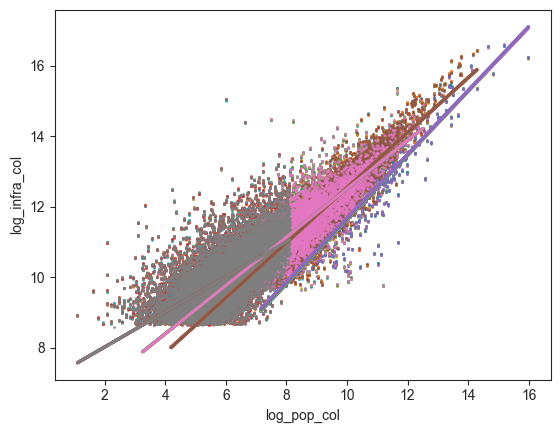

In [48]:
current_stock_col ='cl_length_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2040, on ='GEOID')
print(roads_clean.shape)

df_for_analysis.rename({'surface_Res_at_2040' : 'cl_length_at_2040'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2050, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2050' : 'cl_length_at_2050'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2060, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2060' : 'cl_length_at_2060'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2060'
current_pop_col = 'ssp22060'
next_pop_col = 'ssp22070'
t = 2070

df_for_2070 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2070, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2070, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2070' : 'cl_length_at_2070'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2070'
current_pop_col = 'ssp22070'
next_pop_col = 'ssp22080'
t = 2080

df_for_2080 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2080, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2080, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2080' : 'cl_length_at_2080'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2080'
current_pop_col = 'ssp22080'
next_pop_col = 'ssp22090'
t = 2090

df_for_2090 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2090, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2090, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2090' : 'cl_length_at_2090'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2090'
current_pop_col = 'ssp22090'
next_pop_col = 'ssp22100'
t = 2100

df_for_2100 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2100, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2100, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2100' : 'cl_length_at_2100'}, axis=1, inplace=True)


In [49]:
roads_clean[['State', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 
             'per_cap_mass_at_2050','per_cap_mass_at_2060','per_cap_mass_at_2100']].sort_values(by= 'per_cap_mass_at_2020')

,State,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2030,per_cap_mass_at_2040,per_cap_mass_at_2050,per_cap_mass_at_2060,per_cap_mass_at_2100
5621,15.0,Haliimaile CDP,0.010721,0.009715,0.009013,0.008447,0.007943,0.006631
3846,9.0,Sacred Heart University CDP,0.011010,0.010575,0.010224,0.009954,0.009733,0.009516
16689,34.0,Stockton University CDP,0.013453,0.012972,0.012726,0.012590,0.012406,0.012403
2741,6.0,Marina del Rey CDP,0.030026,0.028901,0.028261,0.027868,0.027639,0.029178
2966,6.0,Rowland Heights CDP,0.076951,0.070746,0.066531,0.063666,0.061482,0.059264
...,...,...,...,...,...,...,...,...
23405,42.0,Fort Indiantown Gap CDP,3974.013093,3814.888880,3716.157434,3669.579802,3577.741815,3492.635690
2637,6.0,Johnsville CDP,4744.337092,5218.770801,5798.634223,6139.730354,6958.361068,9488.674183
15167,30.0,Niarada CDP,6032.399989,5837.147318,5838.105049,6046.608801,5843.352210,6054.412216
19475,38.0,Calio city,7356.666596,7406.496349,6617.528405,6642.095804,6670.621075,6130.935946


In [50]:
roads_clean[(roads_clean['per_cap_mass_at_2020'] < roads_clean['per_cap_mass_at_2050']) & (roads_clean['ssp22050'] > roads_clean['CensusPop_20'])][['NAMELSAD', 'CensusPop_20',
              'ssp22040', 'ssp22050', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2050', 'cl_total_length','surface_Res_at_2040','surface_Res_at_2050']]

,NAMELSAD,CensusPop_20,ssp22040,ssp22050,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2050,cl_total_length,surface_Res_at_2040,surface_Res_at_2050
472,Bristow Cove CDP,624.0,633.473076,624.077438,32.679218,32.226825,32.691635,20391.831999,20399.580223,20399.580223
582,Underwood-Petersville CDP,3051.0,3093.784308,3054.283389,21.735474,21.479692,21.761024,66314.930475,66458.168235,66458.168235
675,Nogales city,19770.0,20002.246870,19786.546260,15.732319,15.567290,15.736440,311027.937533,311376.937980,311376.937980
1539,Beirne CDP,36.0,36.002106,36.000222,27.151858,27.152025,27.152025,977.466902,977.472887,977.472887
2245,Butte Meadows CDP,74.0,75.142456,74.196732,182.204565,179.957666,182.389527,13483.137776,13496.824967,13496.824967
...,...,...,...,...,...,...,...,...,...,...
29914,Maine village,2613.0,2663.258940,2615.919491,104.408098,102.573576,104.416450,272818.359286,273153.432367,273153.432367
30072,Almond village,424.0,431.647702,424.130968,36.868884,36.206341,36.889480,15632.406690,15641.139520,15641.139520
30074,Amherst Junction village,383.0,389.969816,383.006778,47.811899,46.980919,47.839578,18311.957140,18322.558398,18322.558398
30076,Nelsonville village,158.0,160.993787,158.022243,40.352680,39.639435,40.392082,6375.723386,6381.948986,6381.948986


In [51]:
roads_clean[(roads_clean['per_cap_mass_at_2020'] > roads_clean['per_cap_mass_at_2050']) & (roads_clean['ssp22050'] < roads_clean['CensusPop_20'])][['State', 
                        'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2050', 'cl_total_length','surface_Res_at_2050']]

,State,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2050,cl_total_length,surface_Res_at_2050
971,4.0,Sunwest CDP,417.777880,417.777880,2088.889399,2088.889399
9745,20.0,Nicodemus CDP,772.885942,772.885942,10820.403187,10820.403187


### PLOTS

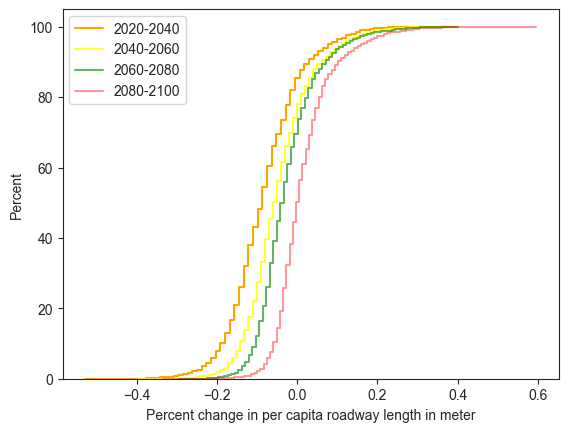

In [52]:
# roads_clean[roads_clean['per_cap_mass_at_2100'] < roads_clean['per_cap_mass_at_2020']]['per_cap_mass_at_2020'].describe()
data = roads_clean[roads_clean['city type'] == 'suburban']

stat_method = 'percent'
cumulative_method = True

sns.histplot(np.sort((data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']), alpha = 1.0, color= 'orange', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']), alpha = 0.8, color= 'yellow', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']), alpha = 0.6, color ='green', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']), alpha = 0.4, color ='red', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
plt.xlabel('Percent change in per capita roadway length in meter')
plt.legend(labels=['2020-2040', '2040-2060', '2060-2080', '2080-2100'])

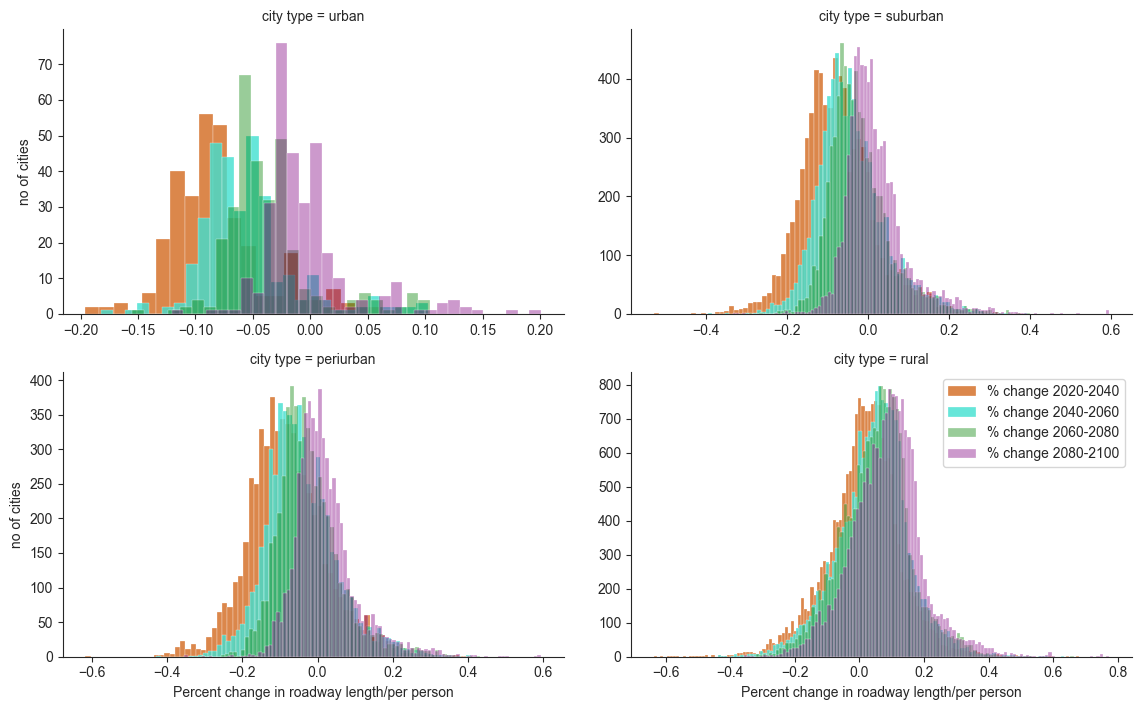

In [53]:
data = roads_clean

data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']
data['percent change from 2020-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2020-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2060-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']


citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
                  sharex=False, sharey=False, margin_titles=False, height=3.6, aspect=1.6)
g.map(sns.histplot,'percent change from 2020-2040', alpha = 0.8, color= 'chocolate', linewidth=0.2)
g.map(sns.histplot,'percent change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2)
g.map(sns.histplot,'percent change from 2060-2080', alpha = 0.4, color= 'green', linewidth=0.2)
g.map(sns.histplot,'percent change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2)
g.set_axis_labels("Percent change in roadway length/per person", "no of cities")
plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

In [54]:
# data.columns

In [55]:
# data = roads_clean
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100', 'percent change from 2020-2060',
                           'percent change from 2060-2100','percent change from 2020-2100']].max()

,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100,percent change from 2020-2060,percent change from 2060-2100,percent change from 2020-2100
city type,,,,,,,
periurban,0.405207,0.407933,0.431520,0.594136,0.978383,1.145062,2.592195
rural,0.679612,0.634921,0.663934,0.773913,1.746032,1.537500,4.263158
suburban,0.378141,0.394456,0.400749,0.595450,0.921757,1.145847,2.885870
urban,0.063388,0.102610,0.104398,0.200401,0.172502,0.325651,0.441992


In [56]:
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100','percent change from 2020-2060',
                           'percent change from 2060-2100','percent change from 2020-2100']].min()

,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100,percent change from 2020-2060,percent change from 2060-2100,percent change from 2020-2100
city type,,,,,,,
periurban,-0.618193,-0.430396,-0.311079,-0.354809,-0.782521,-0.465074,-0.883665
rural,-0.636625,-0.439086,-0.319363,-0.356784,-0.796178,-0.482309,-0.892481
suburban,-0.529055,-0.394679,-0.294318,-0.334677,-0.714927,-0.450815,-0.843442
urban,-0.195850,-0.182255,-0.155154,-0.120587,-0.342410,-0.257031,-0.511431


In [57]:
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean()

,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100
city type,,,,
periurban,-0.083939,-0.043566,-0.022215,0.019620
rural,0.011595,0.043134,0.052187,0.086287
suburban,-0.078009,-0.041235,-0.021594,0.018547
urban,-0.080757,-0.054856,-0.035890,-0.003657


In [58]:
data.groupby('city type')[['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].quantile([0.5])*100

,,percent change from 2020-2040,percent change from 2040-2060,percent change from 2060-2080,percent change from 2080-2100
city type,,,,,
periurban,0.5,-9.007879,-5.332157,-3.347355,0.735911
rural,0.5,1.801310,5.084746,5.889433,8.992767
suburban,0.5,-8.371802,-5.104603,-3.360176,0.448517
urban,0.5,-8.591525,-6.235478,-4.534147,-1.361804


In [59]:
cols = ['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100','percent change from 2020-2060',
                           'percent change from 2060-2100','percent change from 2020-2100']
for col in cols:
    print(col, np.round((data[data[col] < 0].shape[0] / data.shape[0]), 2))

percent change from 2020-2040 0.59
percent change from 2040-2060 0.49
percent change from 2060-2080 0.45
percent change from 2080-2100 0.31
percent change from 2020-2060 0.54
percent change from 2060-2100 0.39
percent change from 2020-2100 0.47


In [60]:
data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']][['per_cap_mass_at_2020', 'per_cap_mass_at_2050','per_cap_mass_at_2100', 'cl_total_length','surface_Res_at_2050', 'surface_Res_at_2100',
                                                                   'CensusPop_20', 'ssp22050', 'ssp22100']]

,per_cap_mass_at_2020,per_cap_mass_at_2050,per_cap_mass_at_2100,cl_total_length,surface_Res_at_2050,surface_Res_at_2100,CensusPop_20,ssp22050,ssp22100
2,52.773100,54.006098,66.064063,42007.387675,42016.744153,42016.744153,796.0,777.721488,636.435207
5,67.268508,75.575764,98.784069,75273.460950,75273.460950,75273.460950,1119.0,995.672843,761.781631
7,64.608725,73.838543,93.976327,2067.479202,2067.479202,2067.479202,32.0,28.397473,22.006443
8,42.721415,46.294622,57.596968,100737.096789,100737.096789,100737.096789,2358.0,2176.363516,1749.301247
11,33.723772,41.535767,42.013384,316834.833773,316834.833773,317117.023137,9395.0,7627.783150,7547.638569
...,...,...,...,...,...,...,...,...,...
30455,818.005799,848.172528,992.542320,46626.330516,46649.489019,46649.489019,57.0,54.996094,46.644361
30456,120.434071,129.917069,124.177277,65997.870938,65997.870938,66062.311209,548.0,508.436891,531.622989
30465,162.335626,171.417340,211.316203,24512.679567,24512.679567,24512.679567,151.0,142.744884,115.521186
30477,713.895181,738.656144,787.899887,23558.540966,23636.996623,23636.996623,33.0,31.825684,30.053340


In [61]:
np.sum(data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['ssp22050'].round(0) * data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['per_cap_mass_at_2050'] - \
data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['CensusPop_20'] * data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['per_cap_mass_at_2020'])

113753.38160967536

In [62]:
data[(data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020'])]['cl_total_length'].sum() - data[(data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020'])]['surface_Res_at_2050'].sum(), \
data[(data['per_cap_mass_at_2100'] > data['per_cap_mass_at_2050'])]['surface_Res_at_2100'].sum() -data[(data['per_cap_mass_at_2100'] > data['per_cap_mass_at_2050'])]['surface_Res_at_2050'].sum() 

(-113753.38160967827, 262228.50130832195)

In [63]:
np.sum(data[data['per_cap_mass_at_2050'] < data['per_cap_mass_at_2020']]['per_cap_mass_at_2050'])

585606.5541946146

In [64]:
np.sum(data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['per_cap_mass_at_2050'] - data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['per_cap_mass_at_2020'])/1000, \
np.sum(-data[data['per_cap_mass_at_2050'] < data['per_cap_mass_at_2100']]['per_cap_mass_at_2050'] + data[data['per_cap_mass_at_2050'] < data['per_cap_mass_at_2100']]['per_cap_mass_at_2100'])/1000 

(137.02367931719718, 378.44368911786495)

In [65]:
np.sum(data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['surface_Res_at_2050'] - data[data['per_cap_mass_at_2050'] > data['per_cap_mass_at_2020']]['cl_total_length'])/1000, \
np.sum(data[data['per_cap_mass_at_2100'] > data['per_cap_mass_at_2050']]['surface_Res_at_2100'] - data[data['per_cap_mass_at_2100'] > data['per_cap_mass_at_2050']]['surface_Res_at_2050'])/1000

(113.75338160967814, 262.2285013082536)

In [66]:
data[data['per_cap_mass_at_2050'] < data['per_cap_mass_at_2100']][['per_cap_mass_at_2020', 'per_cap_mass_at_2050','per_cap_mass_at_2100', 'cl_total_length','surface_Res_at_2050', 'surface_Res_at_2100',]]

,per_cap_mass_at_2020,per_cap_mass_at_2050,per_cap_mass_at_2100,cl_total_length,surface_Res_at_2050,surface_Res_at_2100
2,52.773100,54.006098,66.064063,42007.387675,42016.744153,42016.744153
3,27.275827,26.874482,28.258859,68898.738166,69121.168148,69121.168148
5,67.268508,75.575764,98.784069,75273.460950,75273.460950,75273.460950
6,43.059827,42.131978,45.113968,187783.905675,188035.019141,188035.019141
7,64.608725,73.838543,93.976327,2067.479202,2067.479202,2067.479202
...,...,...,...,...,...,...
30477,713.895181,738.656144,787.899887,23558.540966,23636.996623,23636.996623
30481,62.663302,58.858097,67.051412,23561.401489,23602.096860,23602.096860
30485,142.251332,137.302302,157.751581,14794.138501,14828.648636,14828.648636
30487,202.724298,195.964415,227.635431,45004.794121,45071.815403,45071.815403


In [67]:
roads_clean[roads_clean['NAMELSAD'].str.startswith('Trinity')][['CensusPop_20', 'ssp22030','ssp22040','ssp22050','ssp22100', 'per_cap_mass_at_2020', 'per_cap_mass_at_2050',
                                'per_cap_mass_at_2100', 'cl_total_length','surface_Res_at_2030', 'surface_Res_at_2040','surface_Res_at_2050', 'surface_Res_at_2100',]].round(2)

,CensusPop_20,ssp22030,ssp22040,ssp22050,ssp22100,per_cap_mass_at_2020,per_cap_mass_at_2050,per_cap_mass_at_2100,cl_total_length,surface_Res_at_2030,surface_Res_at_2040,surface_Res_at_2050,surface_Res_at_2100
3,2526.0,2577.68,2585.72,2571.51,2446.13,27.28,26.87,28.26,68898.74,69092.62,69121.17,69121.17,69121.17
3115,198.0,179.39,159.65,142.34,84.77,163.84,228.46,381.66,32440.80,32440.80,32440.80,32440.80,32440.80
3116,278.0,256.92,230.98,209.12,129.72,146.28,194.58,312.82,40666.77,40666.77,40666.77,40666.77,40666.77
4856,11924.0,13403.88,14724.74,15876.84,19221.63,11.12,8.60,7.23,132584.68,134197.68,135493.02,136472.85,138941.29
18993,7006.0,7294.55,7434.46,7468.31,7140.26,33.26,31.42,32.88,232991.54,234038.31,234531.31,234647.28,234752.51
26631,2343.0,2237.47,2112.94,2016.93,1656.82,44.96,52.23,63.58,105345.12,105345.12,105345.12,105345.12,105345.12


In [68]:
19.36*(2571.51**0.77), 19.36*(2571.51**0.76) # 0.74-0.76, 0.77-0.78

(8179.943057767155, 7562.204164873454)

c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\mi

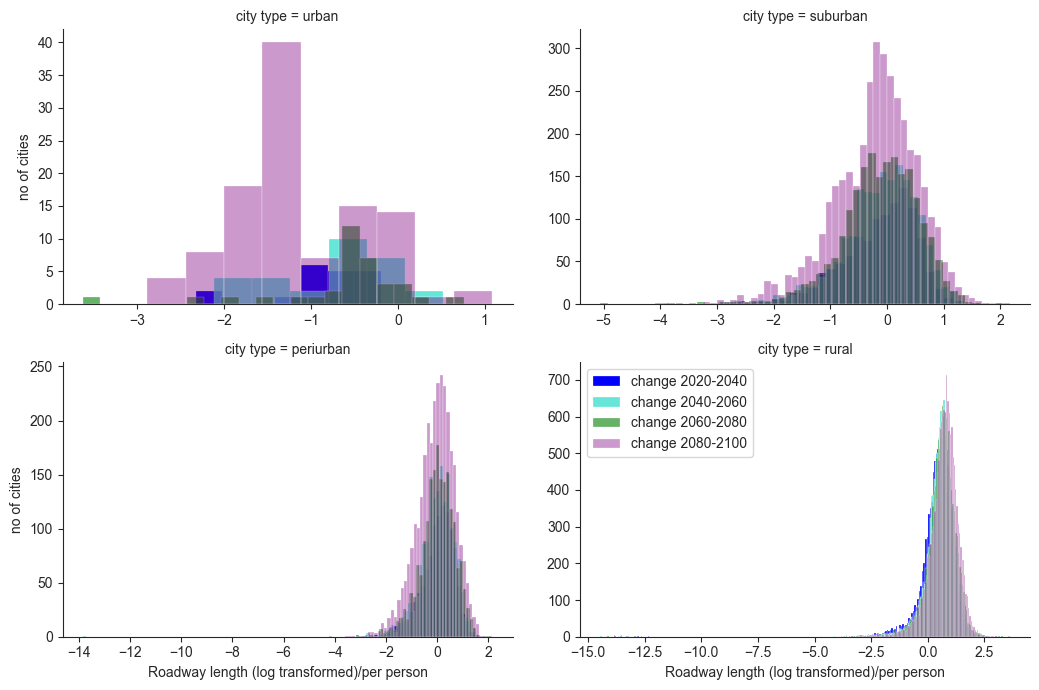

In [69]:
data = roads_clean

data['m-change from 2020-2040'] = np.log10(data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])
data['m-change from 2040-2060'] = np.log10(data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])
data['m-change from 2060-2080'] = np.log10(data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])
data['m-change from 2080-2100'] = np.log10(data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])

citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
                  sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)
g.map(sns.histplot,'m-change from 2020-2040', alpha = 1.0, color= 'blue', linewidth=0.2)
g.map(sns.histplot,'m-change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2)
g.map(sns.histplot,'m-change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2)
g.map(sns.histplot,'m-change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2)
g.set_axis_labels("Roadway length (log transformed)/per person", "no of cities")
plt.legend(labels=['change 2020-2040', 'change 2040-2060', 'change 2060-2080', 'change 2080-2100'])

In [70]:
# # import matplotlib
# # matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# # fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
# data = roads_clean
# data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
# data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
# data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
# data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']


# g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
#                   sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)

# g.map(sns.histplot,'percent change from 2020-2040', alpha = 1.0, color= 'Tan', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2, kde=True, fill = False)
# g.set_axis_labels("Percent change in roadway length/per person", "no of cities")
# plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

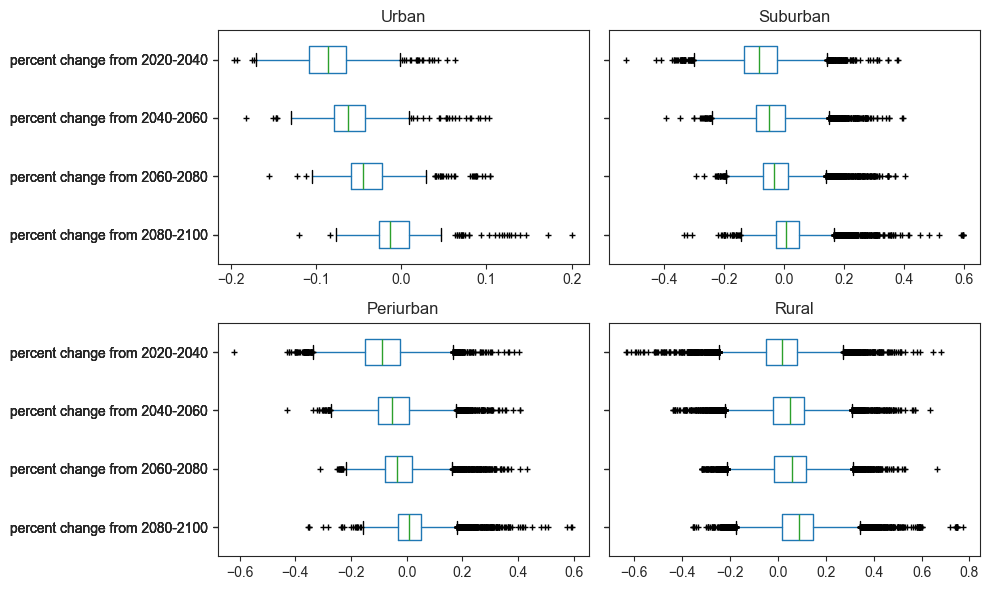

In [71]:
columns_boxplot = ['percent change from 2080-2100', 'percent change from 2060-2080','percent change from 2040-2060','percent change from 2020-2040']

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
roads_clean[roads_clean['city type'] == 'urban'][columns_boxplot].boxplot(ax=axs[0, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
# # Boxplot for Value1 and Value3 in the second subplot
roads_clean[roads_clean['city type'] == 'suburban'][columns_boxplot].boxplot(ax=axs[0, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
roads_clean[roads_clean['city type'] == 'periurban'][columns_boxplot].boxplot(ax=axs[1, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
roads_clean[roads_clean['city type'] == 'rural'][columns_boxplot].boxplot(ax=axs[1, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    # ax.axis("off")
    ax.grid(False)

In [72]:
columns_boxplot = ['percent change from 2080-2100', 'percent change from 2060-2080','percent change from 2040-2060','percent change from 2020-2040']
region = ['Northeast', 'Midwest', 'West', 'South']

def groupbyBoxplot(df, groupCol1, groupCol2, groupCol2Pos, columns_boxplot = columns_boxplot):
    print("Making plot for ", region[groupCol2Pos])

    # Create a figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

    # Boxplot for Value1 and Value2 in the first subplot
    df[(df[groupCol1] == 'urban') & (df[groupCol2] == region[groupCol2Pos])][columns_boxplot].boxplot(ax=axs[0, 0], vert=False, sym='+',
                                                                            flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
    axs[0, 0].set_title('Urban')
    # # Boxplot for Value1 and Value3 in the second subplot
    df[(df[groupCol1] == 'urban') & (df[groupCol2] == region[groupCol2Pos])][columns_boxplot].boxplot(ax=axs[0, 1], vert=False, sym='+',
                                                                            flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
    axs[0, 1].set_title('Suburban')
    # # Boxplot for Value2 and Value3 in the third subplot
    df[(df[groupCol1] == 'urban') & (df[groupCol2] == region[groupCol2Pos])][columns_boxplot].boxplot(ax=axs[1, 0], vert=False, sym='+',
                                                                            flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
    axs[1, 0].set_title('Periurban')
    # # Boxplot for all three values in the fourth subplot
    df[(df[groupCol1] == 'urban') & (df[groupCol2] == region[groupCol2Pos])][columns_boxplot].boxplot(ax=axs[1, 1], vert=False, sym='+',
                                                                            flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
    axs[1, 1].set_title('Rural')
    # Adjust layout
    plt.tight_layout()

    for ax in fig.axes:
        # ax.axis("off")
        ax.grid(False)

C:\Users\uttar\AppData\Local\Temp\ipykernel_14316\2446713639.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize' :12})
C:\Users\uttar\AppData\Local\Temp\ipykernel_14316\2446713639.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["2020-2040","2040-2060", "2060-2080", "2080-2100"], fontdict={'fontsize' :12})
C:\Users\uttar\AppData\Local\Temp\ipykernel_14316\2446713639.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize' :12})
C:\Users\uttar\AppData\Local\Temp\ipykernel_14316\2446713639.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

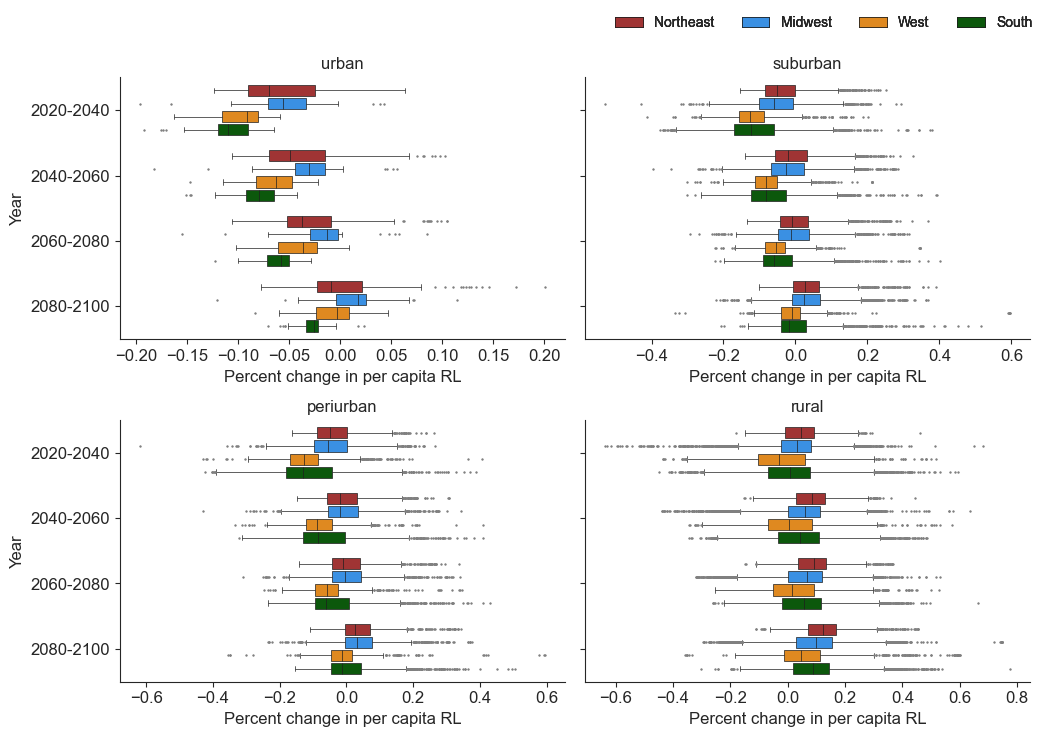

In [73]:
custom_order = ['Northeast','Midwest', 'West','South'] 
flierprops = dict(marker='+', markerfacecolor='None', markersize=2,  markeredgecolor='grey')

fig, ax = plt.subplots(nrows = 2, ncols = 2,figsize=(14, 7), sharey = True)
for ax, city in zip(ax.flatten(), citytype_name):
    df = roads_clean[(roads_clean['city type'] == city)]
    df_melted = pd.melt(df, id_vars='REGION', value_vars=['percent change from 2020-2040','percent change from 2040-2060', 'percent change from 2060-2080','percent change from 2080-2100'])
    sns.boxplot(ax =ax, data=df_melted,  y='variable', x='value', hue="REGION", gap= 0.15, legend=True, linewidth = 0.5, hue_order=custom_order, palette= ['firebrick','dodgerblue', 'darkorange','darkgreen'],
                flierprops=flierprops)
    ax.get_legend().remove()
    ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize' :12}) 
    ax.set_yticklabels(["2020-2040","2040-2060", "2060-2080", "2080-2100"], fontdict={'fontsize' :12}) 
    ax.set_xlabel('Percent change in per capita RL', fontdict={'fontsize' :12})  
    ax.set_ylabel('Year', fontdict={'fontsize' :12}) 
    ax.set_title(city) 

for ax in fig.axes:
    # ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right',  ncol=4, bbox_to_anchor=(0.75, 1), frameon=False)
plt.tight_layout(rect=[0, 0, 0.75, 1])
# plt.savefig(r'D:\Work\Box Sync\Quantify Infrastructure\Figures\demo_RL.png', transparent=True, format='png', dpi=300,bbox_inches='tight')

In [74]:
# groupbyBoxplot(roads_clean, 'city type', 'REGION', 1)

In [75]:
# groupbyBoxplot(roads_clean, 'city type', 'REGION', 2)

In [76]:
# groupbyBoxplot(roads_clean, 'city type', 'REGION', 3)

In [77]:
df_check = roads_clean[['GEOID','NAMELSAD', 'city type', 'REGION', 'weighted_HU_density_sqmi','cl_total_length', 'surface_Res_at_2030', 'surface_Res_at_2040', 'surface_Res_at_2050', 'surface_Res_at_2060', 'surface_Res_at_2070', 'surface_Res_at_2080', 'surface_Res_at_2090', 'surface_Res_at_2100', 
'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100', 'per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040',
       'per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100']]

In [78]:
roads_clean['m-from 2020-2030'] = roads_clean['per_cap_mass_at_2030'] - roads_clean['per_cap_mass_at_2020']
roads_clean['m-from 2030-2040'] = roads_clean['per_cap_mass_at_2040'] - roads_clean['per_cap_mass_at_2030']
roads_clean['m-from 2040-2050'] = roads_clean['per_cap_mass_at_2050'] - roads_clean['per_cap_mass_at_2040']
roads_clean['m-from 2050-2060'] = roads_clean['per_cap_mass_at_2060'] - roads_clean['per_cap_mass_at_2050']
roads_clean['m-from 2060-2070'] = roads_clean['per_cap_mass_at_2070'] - roads_clean['per_cap_mass_at_2060']
roads_clean['m-from 2070-2080'] = roads_clean['per_cap_mass_at_2080'] - roads_clean['per_cap_mass_at_2070']
roads_clean['m-from 2080-2090'] = roads_clean['per_cap_mass_at_2090'] - roads_clean['per_cap_mass_at_2080']
roads_clean['m-from 2090-2100'] = roads_clean['per_cap_mass_at_2100'] - roads_clean['per_cap_mass_at_2090']

In [79]:
# roads_clean.columns[10:]

In [80]:
# roads_clean['CityName'] = roads_clean['NAMELSAD'].str.split(' ').str[0]
df_check = roads_clean[['GEOID', 'NAMELSAD','future trend from SSP 2', 'city type', 'REGION', 'per_cap_mass_at_2020','per_cap_mass_at_2030','per_cap_mass_at_2040','per_cap_mass_at_2050',
                        'percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100', 'percent change from 2020-2100',
       'percent change from 2020-2060', 'percent change from 2060-2100', 'm-from 2020-2030',
       'm-from 2030-2040', 'm-from 2040-2050', 'm-from 2050-2060',
       'm-from 2060-2070', 'm-from 2070-2080', 'm-from 2080-2090',
       'm-from 2090-2100', 'per_cap_mass_at_2100']]

In [81]:
# import plotly.graph_objects as go
# long_df = df_check[df_check['per_cap_mass_at_2020'] < 1000].sort_values('per_cap_mass_at_2020').tail(100)
# long_df['total'] = long_df[['m-from 2020-2030','m-from 2030-2040', 'm-from 2040-2050', 'm-from 2050-2060',
#                             'm-from 2060-2070', 'm-from 2070-2080', 'm-from 2080-2090', 'm-from 2090-2100']].sum(axis =1)
# long_df = long_df.sort_values('total')

# fig = go.Figure()

# fig.add_trace(go.Barpolar(
#     r=[500]* len(long_df),
#     theta = long_df['NAMELSAD'].values,
#     name='',
#     marker_color='white'
# ))

# fig.add_trace(go.Barpolar(
#     r=long_df['per_cap_mass_at_2020'].values,
#     theta = long_df['NAMELSAD'].values,
#     name='Per capita roadway in 2020',
#     marker_color='gray'
# ))

# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2020-2030'].values,
#     theta = long_df['NAMELSAD'].values,
#     name="added from 2020-2030",
#     marker_color='chocolate'
# ))
# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2030-2040'].values,
#     theta = long_df['NAMELSAD'].values,
#     name="added from 2030-2040",
#     marker_color='darkorange'
# ))
# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2040-2050'].values,
#     theta = long_df['NAMELSAD'].values,
#     name='added from 2040-2050',
#     marker_color='goldenrod'
# ))
# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2050-2060'].values,
#     theta = long_df['NAMELSAD'].values,
#     name="added from 2050-2060",
#     marker_color='coral'
# ))

# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2060-2070'].values,
#     theta = long_df['NAMELSAD'].values,
#     name="added from 2060-2070",
#     marker_color='peru'
# ))
# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2070-2080'].values,
#     theta = long_df['NAMELSAD'].values,
#     name="added from 2070-2080",
#     marker_color='khaki'
# ))
# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2080-2090'].values,
#     theta = long_df['NAMELSAD'].values,
#     name='added from 2080-2090',
#     marker_color='darkkhaki'
# ))
# fig.add_trace(go.Barpolar(
#     r=long_df['m-from 2090-2100'].values,
#     theta = long_df['NAMELSAD'].values,
#     name="added from 2090-2100",
#     marker_color='lightsalmon'
# ))

# fig.update_layout(
#     # title='Temporal change in per capita RL (m)',
#     width =1000,
#     height=750,
#     font_size=16,
#     legend_font_size=16,
#     polar_angularaxis_showticklabels = False,
#     # polar_angularaxis_ticks = 'inside',
#     polar_radialaxis_tickmode = 'array',
#     polar_radialaxis_tickvals = [0, 500, 1000, 1500, 2000, 2500],
#     polar_radialaxis_ticktext = ['', 0, 500, 1000, 1500, 2000],
#     # polar_angularaxis_tickangle=-90,
#     # polar_radialaxis_ticksuffix='%',
#     # polar_angularaxis_rotation=-90,
#     # polar_angularaxis_ticklabelstep=1,

# )
# fig.update_layout({
# 'plot_bgcolor': 'rgba(0, 0, 0, 0)',
# 'paper_bgcolor': 'rgba(0, 0, 0, 0)',
# })
# fig.update_polars(bgcolor='white')
# fig.update_layout(
#     margin=dict(l=0, r=0, t=0, b=0),
# )
# fig.show()
# fig.write_image(r"D:\Work\Box Sync\TRB 2025\top_100_by_percap2020.png")

In [82]:
# roads_clean[roads_clean['future trend from SSP 2'] == 'decreasing'][['m-from 2020-2030',
#        'm-from 2030-2040', 'm-from 2040-2050', 'm-from 2050-2060',
#        'm-from 2060-2070', 'm-from 2070-2080', 'm-from 2080-2090',
#        'm-from 2090-2100']].describe()

### Plot Maps


In [83]:
roads_clean.to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_projected_x_local.csv')

In [84]:
import pandas as pd
import os
import geopandas as gpd
import seaborn as sns

roads_df =  pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_projected_x_local.csv')
roads_df['GEOID'] = roads_df['GEOID'].astype(str).str.rjust(7,'0')
roads_df['percent change from 2020-2030'] = (roads_df['per_cap_mass_at_2030'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']
roads_df['percent change from 2030-2040'] = (roads_df['per_cap_mass_at_2040'] - roads_df['per_cap_mass_at_2030']) / roads_df['per_cap_mass_at_2030']
roads_df['percent change from 2040-2050'] = (roads_df['per_cap_mass_at_2050'] - roads_df['per_cap_mass_at_2040']) / roads_df['per_cap_mass_at_2040']
roads_df['percent change from 2050-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2050']) / roads_df['per_cap_mass_at_2050']
roads_df['percent change from 2060-2070'] = (roads_df['per_cap_mass_at_2070'] - roads_df['per_cap_mass_at_2060']) / roads_df['per_cap_mass_at_2060']
roads_df['percent change from 2070-2080'] = (roads_df['per_cap_mass_at_2080'] - roads_df['per_cap_mass_at_2070']) / roads_df['per_cap_mass_at_2070']
roads_df['percent change from 2080-2090'] = (roads_df['per_cap_mass_at_2090'] - roads_df['per_cap_mass_at_2080']) / roads_df['per_cap_mass_at_2080']
roads_df['percent change from 2090-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2090']) / roads_df['per_cap_mass_at_2090']
roads_df['percent change from 2020-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']
roads_df['percent change from 2060-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2060']) / roads_df['per_cap_mass_at_2060']
roads_df['percent change from 2020-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']

# Define your thresholds
thresholds = [-1.00, -.50, -.10, 0, 0.25, 0.50, 1.00, 2.05]

# Create labels for each category
labels = ["Pressurized", "Overwhelmed" , "Utilized", 'Low Burden', 'Medium Burden', 'High Burden', 'Highest Burden']

# Use pd.cut() to create the categorical variable
roads_df['Burden index_upto_60'] = pd.cut(roads_df['percent change from 2020-2060'], bins=thresholds, labels=labels)
# Use pd.cut() to create the categorical variable
roads_df['Burden index_upto_100'] = pd.cut(roads_df['percent change from 2020-2060'], bins=thresholds, labels=labels)

In [85]:
roads_df['per cap added from 2020-2030'] = (roads_df['per_cap_mass_at_2030'] - roads_df['per_cap_mass_at_2020'])
roads_df['per cap added from 2030-2040'] = (roads_df['per_cap_mass_at_2040'] - roads_df['per_cap_mass_at_2030'])
roads_df['per cap added from 2040-2050'] = (roads_df['per_cap_mass_at_2050'] - roads_df['per_cap_mass_at_2040'])
roads_df['per cap added from 2050-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2050'])
roads_df['per cap added from 2060-2070'] = (roads_df['per_cap_mass_at_2070'] - roads_df['per_cap_mass_at_2060'])
roads_df['per cap added from 2070-2080'] = (roads_df['per_cap_mass_at_2080'] - roads_df['per_cap_mass_at_2070'])
roads_df['per cap added from 2080-2090'] = (roads_df['per_cap_mass_at_2090'] - roads_df['per_cap_mass_at_2080'])
roads_df['per cap added from 2090-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2090'])


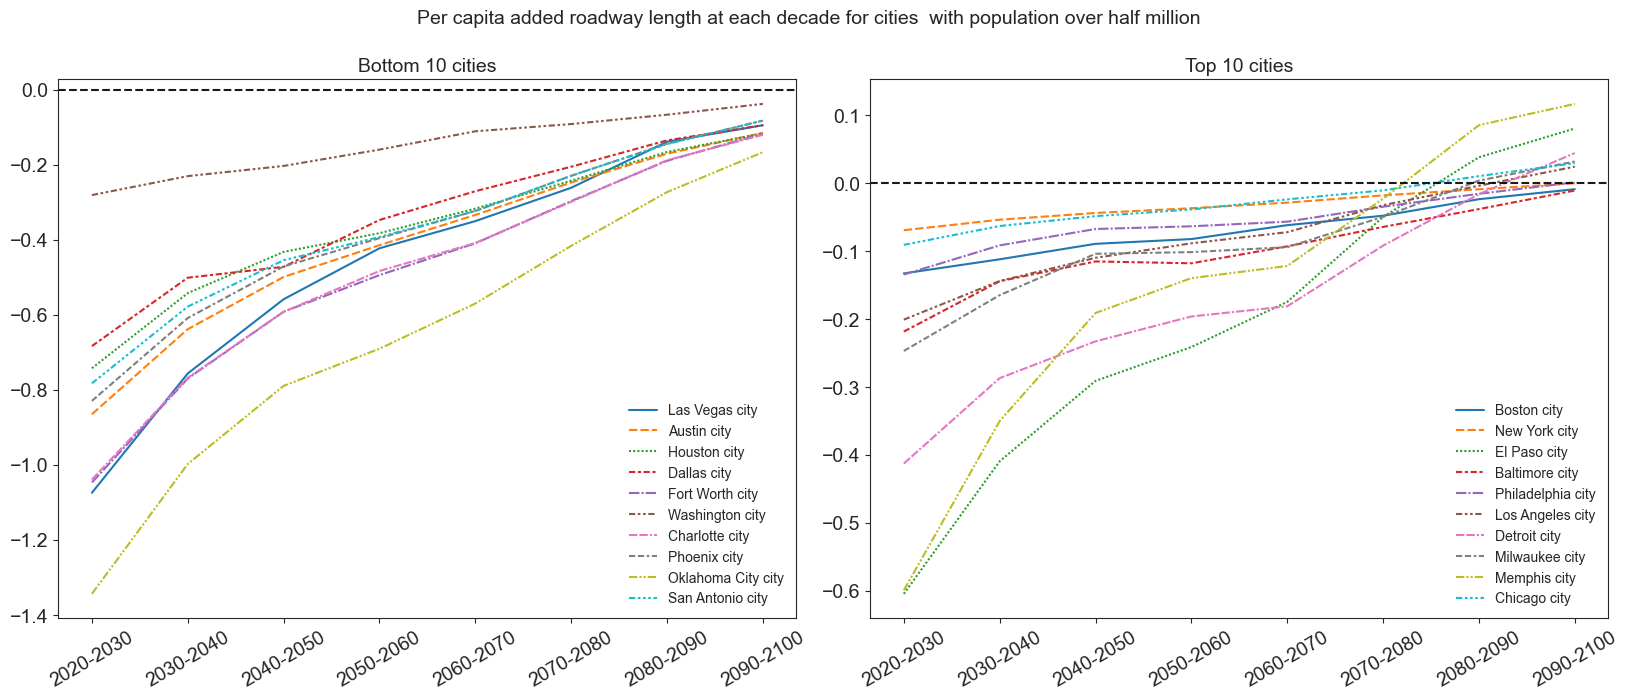

In [86]:
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per cap added from 2020-2030', 'per cap added from 2030-2040',
       'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080',
       'per cap added from 2080-2090', 'per cap added from 2090-2100']]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20,7))
fig.suptitle('Per capita added roadway length at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = 'brief')
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 0.9,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020-2030', '2030-2040','2040-2050','2050-2060','2060-2070','2070-2080','2080-2090','2090-2100'],rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# fig.savefig(figure_filepath + 'Per capita added roadway length at each decade for cities  with population over half million' + '.png', dpi = 300,  bbox_inches='tight')

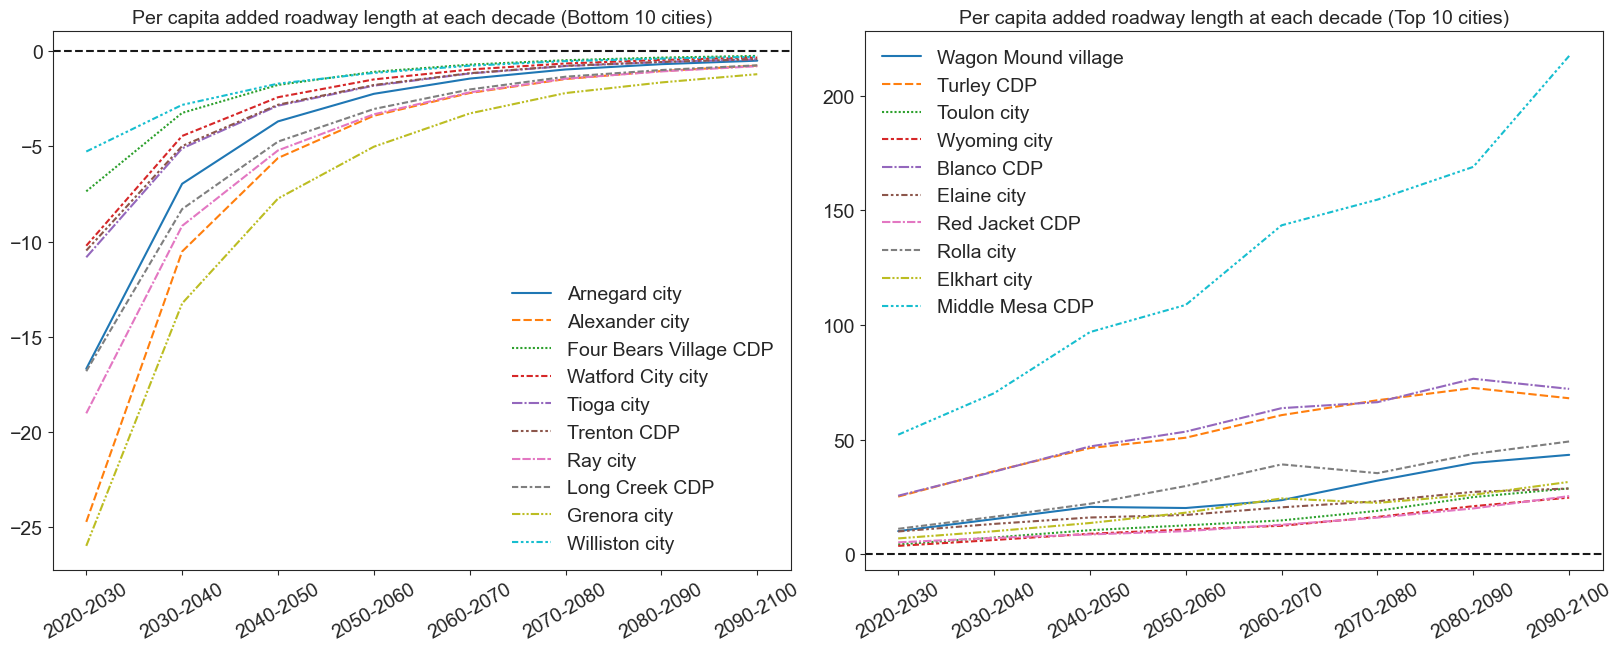

In [87]:
import seaborn as sns
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 100].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per cap added from 2020-2030', 'per cap added from 2030-2040',
       'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080',
       'per cap added from 2080-2090', 'per cap added from 2090-2100']]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20,7))
# fig.suptitle('Top 10 cities with minimum and maximum percent change in per capita roadway')
axes[0].set_title('Per capita added roadway length at each decade (Bottom 10 cities)', fontsize= 14)
axes[1].set_title('Per capita added roadway length at each decade (Top 10 cities)', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = 'brief')
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 0.9,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020-2030', '2030-2040','2040-2050','2050-2060','2060-2070','2070-2080','2080-2090','2090-2100'],rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# fig.savefig(figure_filepath + 'Per capita added roadway length at each decade with population over 100' + '.png', dpi = 300,  bbox_inches='tight')

### starting from zero

In [88]:
roads_df = roads_df.assign(**roads_df[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 
'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100']].sub(roads_df['per_cap_mass_at_2020'], axis=0).add_prefix('sub_'))

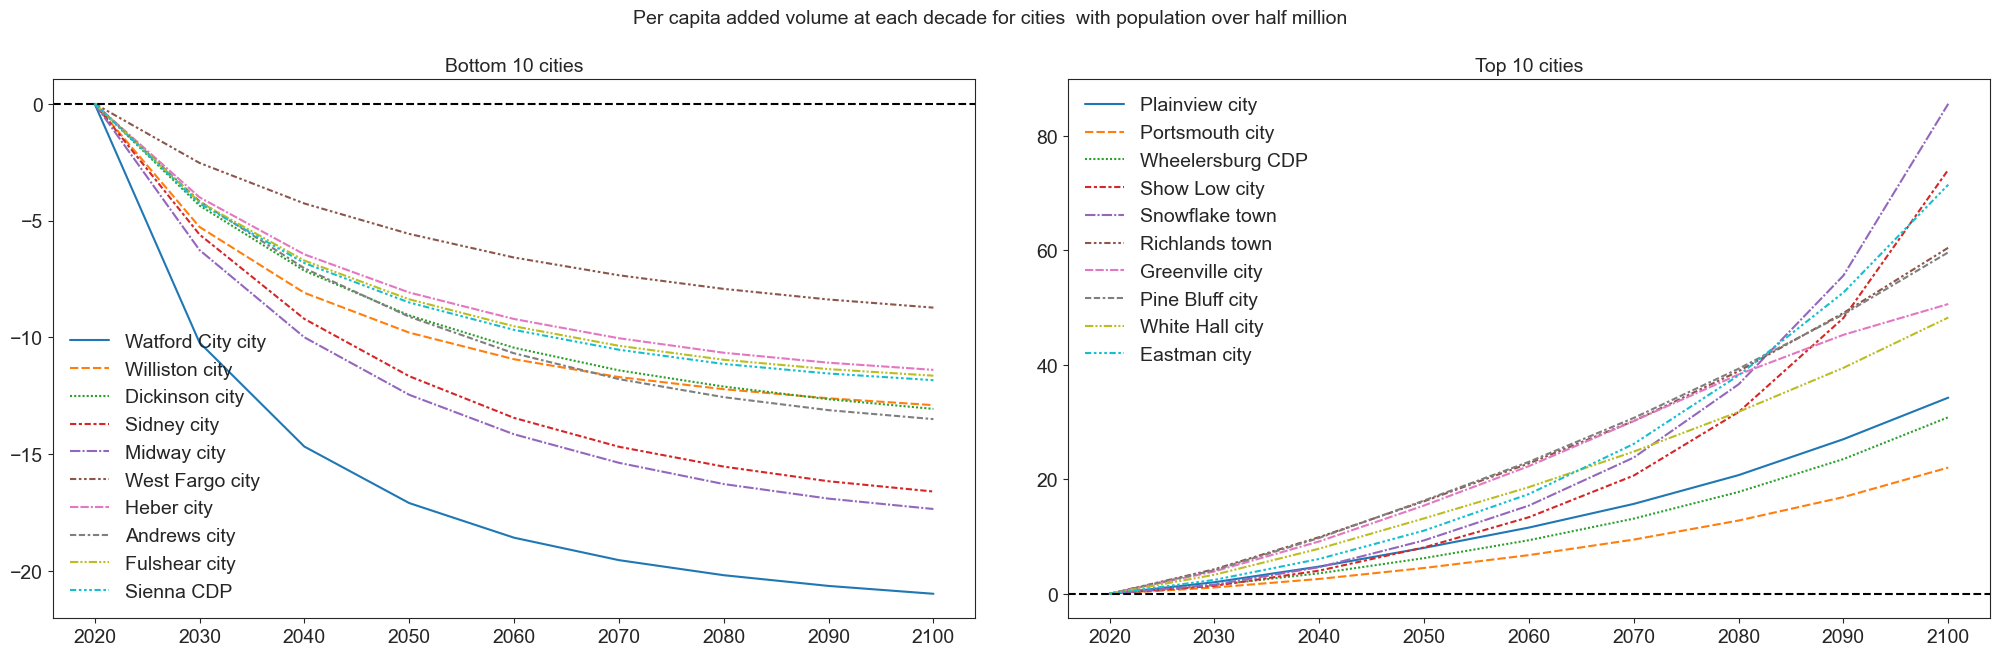

In [89]:
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 5000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 
        'sub_per_cap_mass_at_2020', 'sub_per_cap_mass_at_2030',
       'sub_per_cap_mass_at_2040', 'sub_per_cap_mass_at_2050',
       'sub_per_cap_mass_at_2060', 'sub_per_cap_mass_at_2070',
       'sub_per_cap_mass_at_2080', 'sub_per_cap_mass_at_2090',
       'sub_per_cap_mass_at_2100']]

# building_df_sorted = building_clean[building_clean['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per_cap_mass_at_2020', 
#                                     'per_cap_mass_at_2030',  'per_cap_mass_at_2040',  'per_cap_mass_at_2050',  'per_cap_mass_at_2060', 
#                                     'per_cap_mass_at_2070',  'per_cap_mass_at_2080',  'per_cap_mass_at_2090',  'per_cap_mass_at_2100',]]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(25,7))
fig.suptitle('Per capita added volume at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = True)
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 1,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020', '2030','2040','2050','2060','2070','2080','2090', '2100']) #,rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [90]:
roads_df[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2060', 'per_cap_mass_at_2100', 'percent change from 2060-2100', 'percent change from 2020-2060']].sort_values(by ='percent change from 2060-2100')
roads_df['Percentile Rank'] = roads_df['percent change from 2020-2060'].rank(pct = True) 

roads_df['city_type_pct_rank'] = roads_df.groupby('city type')['percent change from 2020-2060'].rank(pct=True)

In [91]:
# figure_filepath = r'D:\Work\Box Sync\Quantify Infrastructure\Figures\\'

# # # Import cartographic base maps: Cartographic boundary for plotting
# US_counties_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_county_5m.zip') # tl_2020_us_county
# US_states_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_state_5m.zip')  # tl_2020_us_state
# # source: https://gis.stackexchange.com/questions/141580/which-projection-is-best-for-mapping-the-contiguous-united-states
# US_states_cb = US_states_cb.to_crs('EPSG:9311')
# US_counties_cb = US_counties_cb.to_crs('EPSG:9311')

# import matplotlib

# import matplotlib
# def quantile_map_plot(df, list_of_columns, colors = 'viridis', is_county = False, state_code =None, file_path= None, file_name= None):

#     colors = colors
#     cmap = matplotlib.colors.ListedColormap([t[1] for t in sorted(colors.items())]) #Sorting by keys before converting to list


#     if len(list_of_columns) > 1:
        
#         fig, axes = plt.subplots(nrows=1, ncols=len(list_of_columns), figsize=(22,16)) #18,16 #len(list_of_columns)

#         for ax, col in zip(axes.flatten(), list_of_columns):
#             continental_ax = ax

#             if is_county==True:
#                 color_subset = {key: value for key, value in colors.items() if key in  sorted(df[df['STATEFP'] == state_code][col].unique())}
#                 cmap = matplotlib.colors.ListedColormap([t[1] for t in sorted(color_subset.items())])
#                 US_counties_cb[US_counties_cb['STATEFP'] == state_code].plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
#                 df[df['STATEFP'] == state_code].plot(ax= continental_ax, column = col, legend = True, linewidth=0.1, legend_kwds={'loc': 'lower left'}, 
#                             cmap = cmap)
                
#             else:
#                 # Set bounds to fit desired areas in each plot
#                 continental_ax.set_xlim(-2257388.37, 2695859.75)
#                 continental_ax.set_ylim(-2546944.04, 808080.90)

#                 # hawaii_ax = ax.inset_axes([.20, .01, .25, .2])

#                 US_states_cb.plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
#                 df.plot(ax= continental_ax, column = col, legend = True, linewidth=0.1, legend_kwds={'loc': 'lower left'}, cmap = cmap)
            
#                 # US_states_cb[US_states_cb['STATEFP'] == '15'].plot(facecolor = 'none', edgecolor='gray', linewidth=0.2, ax=hawaii_ax)
#                 # print(df_map[df_map['STATEFP'] == '15'][col].unique())
#                 # df_map[df_map['STATEFP'] == '15'].plot(column=col, cmap = matplotlib.colors.ListedColormap(['orange', 'purple']), 
#                 #                             ax=hawaii_ax,  linewidth=0.3, missing_kwds = dict(color='black'))

#             ax.set_title(col)
#             # remove ticks
#             for ax in [continental_ax]: #, hawaii_ax]:
#                 ax.set_yticks([])
#                 ax.set_xticks([])
#                 ax.axis('off')
#                 plt.tight_layout()
#                 plt.axis('off') 
#     else:
#         fig, continental_ax = plt.subplots(figsize=(16,22)) #18,16
#         col = list_of_columns
#         US_counties_cb.plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
#         df.plot(ax= continental_ax, column = col, legend = True, linewidth=0.4, legend_kwds={'loc': 'lower left'}, 
#                         cmap = cmap)
#         continental_ax.axis('off')



In [92]:
# os.environ['USE_PYGEOS'] = '0'
# # Import places map
# places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
# print(places_US.shape)

# places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

# print(places_50_states.shape, roads_df.shape)

In [93]:
# df_map = places_50_states.merge(roads_df, on =['GEOID', 'NAMELSAD'])
# print(df_map.shape)

# df_map = df_map.to_crs('EPSG:9311')
# df_map.columns

In [94]:
# # Function to categorize values based on quartile range
# def categorize_by_quartiles(grouped_df, target_column):
#     # Calculate quartile values
#     Q1 = grouped_df.quantile(0.25)
#     Q3 = grouped_df.quantile(0.75)

#     # Categorize values based on quartiles
#     def categorize_value(value):
#         if value < Q1:
#             return 'Pressurized'
#         elif value > Q3:
#             return 'Oversized'
#         else:
#             return 'Balanced'

#     # Apply categorization to target_column
#     return target_column.apply(categorize_value)

### Add landuse data from 2019

In [95]:
df_nlcd = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GEE_NLCD_landuse\LandCoverbyCity19.csv')
df_nlcd['GEOID'] = df_nlcd['GEOID'].astype(str).str.rjust(7,'0')

column_names = ['Open_water', 'Perennial_ice_snow', 'Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity',
       'Developed_high_intensity', 'Barren_land', 'Deciduous_forest', 'Evergreen_forest', 'Mixed_forest', 'Dwarf_scrub', 'Shrub_scrub',
       'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss', 'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands']

df_nlcd[column_names] = df_nlcd[column_names].div(df_nlcd[column_names].sum(axis=1), axis=0).multiply(100)
df_nlcd = df_nlcd.fillna(0)

df_nlcd['veg_wetland'] = df_nlcd[['Dwarf_scrub', 'Shrub_scrub', 'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss',
       'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands', 'Perennial_ice_snow']].sum(axis=1)
df_nlcd['forest'] = df_nlcd[['Deciduous_forest','Evergreen_forest', 'Mixed_forest']].sum(axis=1)

In [96]:
roads_df_lu = roads_df.merge(df_nlcd[['GEOID', 'Open_water','veg_wetland', 'forest', 'Barren_land', 'Developed_open_space', 
'Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']], on ='GEOID')

roads_df_lu['otherLU'] = roads_df_lu[['Open_water','veg_wetland', 'forest', 'Barren_land']].sum(axis=1)
roads_df_lu['developedLU'] = roads_df_lu[['Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']].sum(axis=1)

In [97]:
roads_df_lu[(roads_df_lu['developedLU'] ==100)][['State', 'CensusPop_20', 'ssp22060', 'city type','weighted_HU_density_sqmi', 'NAMELSAD','road_density_m-sqm',
                                                 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
                                         'otherLU', 'developedLU','REGION','median_income']].sort_values(by ='per_cap_mass_at_2020' ).tail(20)

,State,CensusPop_20,ssp22060,city type,weighted_HU_density_sqmi,NAMELSAD,road_density_m-sqm,per_cap_mass_at_2020,per_cap_mass_at_2060,otherLU,developedLU,REGION,median_income
26660,48.0,79.0,95.752017,periurban,58.298119,Amada Acres CDP,0.008431,19.974341,16.986210,0.0,100.0,South,NaN
26794,48.0,80.0,96.110300,periurban,3.435867,Evergreen CDP,0.058858,20.290706,17.446345,0.0,100.0,South,NaN
14897,30.0,1018.0,1147.825774,rural,156.194336,Browning town,0.028904,20.321773,18.053813,0.0,100.0,West,34886.0
26788,48.0,104.0,126.292773,rural,9.775389,El Socio CDP,0.072936,20.390441,16.985398,0.0,100.0,South,NaN
26951,48.0,175.0,239.919054,periurban,247.995472,Los Altos CDP,0.037399,21.049913,15.999702,0.0,100.0,South,NaN
12052,26.0,4088.0,5119.539671,suburban,1010.313526,Lathrup Village city,0.022528,21.501461,17.653820,0.0,100.0,Midwest,97083.0
2850,6.0,568.0,728.386032,suburban,1179.785747,Olde Stockdale CDP,0.011776,21.869247,17.894316,0.0,100.0,West,168295.0
14201,29.0,860.0,1001.940603,suburban,2005.113097,Edmundson city,0.030818,25.456354,22.446789,0.0,100.0,Midwest,42813.0
3248,8.0,254.0,363.219600,suburban,1882.840552,Garden City town,0.022825,26.276278,19.950334,0.0,100.0,West,38281.0
14336,29.0,316.0,367.885326,suburban,387.821009,Westwood village,0.005209,26.844073,23.822208,0.0,100.0,Midwest,250001.0


In [98]:
# roads_df_lu['road_land_ratio'] = roads_df_lu['road_area_m2']/roads_df_lu['ALAND']

In [99]:
# roads_df_lu[['NAMELSAD','road_area_m2', 'ALAND', 'road_land_ratio', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','cl_total_length','surface_Res_at_2080',
#                                            'otherLU','developedLU', 'median_income']].sort_values('road_land_ratio').tail(20)

In [100]:
np.max(roads_df_lu['cl_total_length']*1000/roads_df_lu['ALAND']), np.mean(roads_df_lu['cl_total_length']*1000/roads_df_lu['ALAND'])

(72.93571301736887, 9.610960543563612)

In [101]:
roads_df_lu[['State', 'NAMELSAD','road_density_m-sqm', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','cl_total_length','surface_Res_at_2080',
                                           'otherLU','developedLU']].sort_values('per_cap_mass_at_2020').tail(20)

,State,NAMELSAD,road_density_m-sqm,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2060,per_cap_mass_at_2100,cl_total_length,surface_Res_at_2080,otherLU,developedLU
30453,56.0,Lance Creek CDP,0.000648,1637.998165,1508.157703,1303.860037,1026.589429,7.043392e+04,7.244337e+04,99.240599,0.759401
9778,20.0,Woodruff CDP,0.004192,1677.033287,1816.786061,1816.786061,1981.948430,2.180143e+04,2.180143e+04,93.619168,6.380832
24887,46.0,Okaton CDP,0.000678,1686.891229,2011.293388,2273.636004,1515.358897,5.229363e+04,5.310206e+04,97.318445,2.681555
26649,48.0,Acala CDP,0.002705,1810.157965,1678.417199,1831.000581,2237.889599,1.991174e+04,2.014101e+04,95.202864,4.797136
30479,56.0,Slater CDP,0.000738,1814.384433,1750.302242,1672.615994,1621.414777,1.415220e+05,1.423938e+05,97.938469,2.061531
2882,6.0,Pearsonville CDP,0.001404,1868.432396,1868.432396,2135.351309,2989.491833,1.494746e+04,1.494746e+04,92.623828,7.376172
17097,35.0,Orogrande CDP,0.004500,1890.977174,2005.581851,2068.256284,2451.266707,6.618420e+04,6.618420e+04,94.075748,5.924252
14323,29.0,Evergreen village,0.001471,1925.678513,2027.466005,2265.991418,3501.986736,3.851357e+04,3.852185e+04,97.393038,2.606962
1002,4.0,Valle CDP,0.001848,2348.039875,2019.324118,1761.242850,1463.979250,1.782162e+06,1.794847e+06,97.981581,2.018419
14321,29.0,River Bend village,0.001909,2505.671081,1967.132268,1999.501590,2065.174506,7.517013e+03,8.223344e+03,81.844663,18.155337


In [102]:
# roads_df_lu[['State','NAMELSAD','road_land_ratio','CensusPop_20', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','cl_total_length','surface_Res_at_2080',
#                                            'otherLU','developedLU']].sort_values('road_land_ratio').head(1000)

In [103]:
# roads_df_lu.groupby('city type')['road_land_ratio'].describe()

In [104]:
roads_df_lu[['State', 'NAMELSAD','road_density_m-sqm', 'CensusPop_20','per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','total_length', 'cl_total_length','surface_Res_at_2080',
                                           'otherLU','developedLU']].sort_values('per_cap_mass_at_2020').head(10)

,State,NAMELSAD,road_density_m-sqm,CensusPop_20,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2060,per_cap_mass_at_2100,total_length,cl_total_length,surface_Res_at_2080,otherLU,developedLU
5621,15.0,Haliimaile CDP,0.000001,1074.0,0.010721,0.009013,0.007943,0.006631,12810.595584,11.514655,11.581249,0.000000,0.000000
3846,9.0,Sacred Heart University CDP,0.000052,1446.0,0.011010,0.010224,0.009733,0.009516,2024.302987,15.920067,16.385698,3.077093,96.922907
16689,34.0,Stockton University CDP,0.000011,2428.0,0.013453,0.012726,0.012406,0.012403,15798.031058,32.662904,32.695408,71.258504,28.741496
2741,6.0,Marina del Rey CDP,0.000154,11373.0,0.030026,0.028261,0.027639,0.029178,3966.592534,341.485128,369.951392,29.138464,70.861536
2966,6.0,Rowland Heights CDP,0.000110,48231.0,0.076951,0.066531,0.061482,0.059264,22916.359191,3711.403914,3734.473435,41.735513,58.264487
24832,46.0,Clark Colony CDP,0.000011,92.0,0.079107,0.078292,0.075224,0.064528,1584.879484,7.277887,7.322175,55.372054,44.627946
21995,41.0,Bellfountain CDP,0.000002,74.0,0.097568,0.087536,0.081968,0.074094,8238.623011,7.219995,7.322522,92.267876,7.732124
3048,6.0,South Whittier CDP,0.000598,56415.0,0.146627,0.127916,0.118980,0.116158,31163.758746,8271.942136,8315.523706,0.624326,99.375674
2143,6.0,Alondra Park CDP,0.000550,8569.0,0.183723,0.168561,0.161004,0.158889,9649.978986,1574.321700,1732.526988,2.067872,97.932128
2520,6.0,Hacienda Heights CDP,0.000387,54191.0,0.206098,0.179657,0.166995,0.162900,21350.088433,11168.657987,11228.522828,22.136329,77.863671


In [105]:
import pandas as pd


def gini_coefficient(values):
    sorted_values = sorted(values)
    n = len(values)
    coef = 0
    for i, x in enumerate(sorted_values):
        coef += (i + 1) * x
    coef = 2 * coef / (n * sum(sorted_values)) - (n + 1) / n
    return coef

column_names = ['per_cap_mass_at_2020','per_cap_mass_at_2030','per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060',
                'per_cap_mass_at_2070', 'per_cap_mass_at_2080','per_cap_mass_at_2090','per_cap_mass_at_2100']

gini_values = []
# Calculate Gini coefficient for each variable
for col in column_names:
    df = roads_df_lu
    threshold_u = df[col].quantile(0.9)
    df = df[df[col] < threshold_u]
    gini = gini_coefficient(df[col])
    print(gini)
    gini_values.append(gini)

0.3623118614958407
0.3709198794348285
0.38061799386525497
0.3904102555127944
0.39942537728096483
0.4085924423272347
0.4178809725728796
0.4267156722848817
0.43536450734863785


In [106]:
roads_df_lu.shape

(30498, 209)

In [107]:
roads_perCap = roads_df_lu.rename(columns={'per_cap_mass_at_2020': 'length_m_perCap_2020','per_cap_mass_at_2030': 'length_m_perCap_2030', 'per_cap_mass_at_2040': 'length_m_perCap_2040', 
                            'per_cap_mass_at_2050': 'length_m_perCap_2050', 'per_cap_mass_at_2060': 'length_m_perCap_2060', 'per_cap_mass_at_2070': 'length_m_perCap_2070', 
                            'per_cap_mass_at_2080': 'length_m_perCap_2080', 'per_cap_mass_at_2090': 'length_m_perCap_2090', 'per_cap_mass_at_2100': 'length_m_perCap_2100',})

roads_perCap[['GEOID', 'NAMELSAD','length_m_perCap_2020','length_m_perCap_2030', 'length_m_perCap_2040', 'length_m_perCap_2050', 'length_m_perCap_2060', 
              'length_m_perCap_2070', 'length_m_perCap_2080', 'length_m_perCap_2090', 'length_m_perCap_2100','label','future trend from SSP 2','weighted_HU_density_sqmi', 'median_income',
               'Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity', 'otherLU', 'developedLU', 
               'road_density_m-sqm', 'citytype_at_2030', 'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060', 'citytype_at_2070', 'citytype_at_2080', 'citytype_at_2090',
                 'citytype_at_2100']].to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_perCap_ssp2_x_local.csv')

In [108]:
roads_df_lu[roads_df_lu['NAMELSAD']== 'Stone Park village'][['city type', 'weighted_HU_density_sqmi', 'median_income']]

,city type,weighted_HU_density_sqmi,median_income
6938,urban,4116.083354,63710.0


In [109]:
roads_df_lu[['GEOID', 'NAMELSAD','cl_total_length', 'surface_Res_at_2040', 'total_length','per_cap_mass_at_2020','per_cap_mass_at_2030','per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060',
              ]].sort_values(by = 'per_cap_mass_at_2020',)

,GEOID,NAMELSAD,cl_total_length,surface_Res_at_2040,total_length,per_cap_mass_at_2020,per_cap_mass_at_2030,per_cap_mass_at_2040,per_cap_mass_at_2050,per_cap_mass_at_2060
5621,1510900,Haliimaile CDP,1.151465e+01,1.154511e+01,1.281060e+04,0.010721,0.009715,0.009013,0.008447,0.007943
3846,0966086,Sacred Heart University CDP,1.592007e+01,1.614367e+01,2.024303e+03,0.011010,0.010575,0.010224,0.009954,0.009733
16689,3470984,Stockton University CDP,3.266290e+01,3.268155e+01,1.579803e+04,0.013453,0.012972,0.012726,0.012590,0.012406
2741,0645806,Marina del Rey CDP,3.414851e+02,3.620849e+02,3.966593e+03,0.030026,0.028901,0.028261,0.027868,0.027639
2966,0663218,Rowland Heights CDP,3.711404e+03,3.724268e+03,2.291636e+04,0.076951,0.070746,0.066531,0.063666,0.061482
...,...,...,...,...,...,...,...,...,...,...
23405,4226812,Fort Indiantown Gap CDP,2.702329e+05,2.712795e+05,2.341586e+05,3974.013093,3814.888880,3716.157434,3669.579802,3577.741815
2637,0637512,Johnsville CDP,1.043754e+05,1.043754e+05,1.113929e+05,4744.337092,5218.770801,5798.634223,6139.730354,6958.361068
15167,3053725,Niarada CDP,1.689072e+05,1.693050e+05,2.029243e+05,6032.399989,5837.147318,5838.105049,6046.608801,5843.352210
19475,3811580,Calio city,5.885333e+04,5.955776e+04,6.896756e+04,7356.666596,7406.496349,6617.528405,6642.095804,6670.621075


### Check quantiles after dropping outliers (extreme values)

In [110]:
# Function to remove outliers using IQR method and recalculate quantiles for a specific column
def remove_outliers_and_recalculate_quantiles_for_column(df, column_name):
    # Extract the specified column
    column = df[column_name]
    print("Initial dataframe shape", df.shape)

    # Calculate IQR
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    print("quantile values before excluding outliers:")
    print(Q1.round(2), Q3.round(2))

    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame to exclude outliers
    df_filtered = df[(column >= lower_bound) & (column <= upper_bound)]

    # Recalculate quantile values after excluding outliers
    quantiles = df_filtered[column_name].quantile([0.25, 0.75])
    print("quantile values after excluding outliers:")
    print(quantiles)
    print("New dataframe shape", df_filtered.shape)
    print('\n')

    return df_filtered, quantiles

### Plot temporal shift

In [111]:
# roads_clean[['city type','percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].describe()

In [112]:
roads_clean[['GEOID', 'NAMELSAD', 'CensusPop_20',
       'city type', 'weighted_HU_density_sqmi', 'per_cap_mass_at_2020',
       'per_cap_mass_at_2030', 'surface_Res_at_2030', 'per_cap_mass_at_2040',
       'surface_Res_at_2040', 'per_cap_mass_at_2050', 'surface_Res_at_2050',
       'per_cap_mass_at_2060', 'surface_Res_at_2060',]].sort_values(by= 'per_cap_mass_at_2020',).tail(30)

,GEOID,NAMELSAD,CensusPop_20,city type,weighted_HU_density_sqmi,per_cap_mass_at_2020,per_cap_mass_at_2030,surface_Res_at_2030,per_cap_mass_at_2040,surface_Res_at_2040,per_cap_mass_at_2050,surface_Res_at_2050,per_cap_mass_at_2060,surface_Res_at_2060
16005,3249425,Mount Wilson CDP,26.0,rural,0.397496,1229.899913,1332.391573,3.197740e+04,1390.321641,3.197740e+04,1522.733226,3.197740e+04,1598.869887,3.197740e+04
21534,4009900,Bunch CDP,70.0,rural,10.588038,1248.320305,1285.035608,8.738242e+04,1365.350334,8.738242e+04,1432.498711,8.738242e+04,1533.024936,8.738242e+04
19603,3842660,Kief city,8.0,rural,2.116960,1293.629126,1164.204032,1.047784e+04,1169.314686,1.052383e+04,1179.794312,1.061815e+04,1073.427396,1.073427e+04
9747,2051550,Norway CDP,17.0,rural,2.579966,1335.231346,1418.683305,2.269893e+04,1621.352348,2.269893e+04,1746.071760,2.269893e+04,1637.580388,2.292613e+04
17213,3577950,Timberon CDP,345.0,rural,0.676298,1388.060905,1384.107724,4.789013e+05,1392.154862,4.789013e+05,1408.533154,4.789013e+05,1416.867670,4.789013e+05
17095,3554097,Old Town CDP,27.0,rural,1.003679,1440.090034,1495.478112,3.888243e+04,1495.478112,3.888243e+04,1620.101288,3.888243e+04,1690.540475,3.888243e+04
17110,3556950,Pie Town CDP,166.0,rural,0.391220,1444.579225,1620.271293,2.398002e+05,1830.535506,2.398002e+05,2015.127322,2.398002e+05,2122.125233,2.398002e+05
3626,0858960,Piedra CDP,31.0,rural,1.291587,1521.991486,1572.724536,4.718174e+04,1626.956416,4.718174e+04,1747.471706,4.718174e+04,1814.682157,4.718174e+04
2770,0647794,Mineral CDP,136.0,rural,2.284139,1531.099502,1553.951733,2.082295e+05,1614.182421,2.082295e+05,1692.923027,2.082295e+05,1764.657053,2.082295e+05
2692,0641789,Little Grass Valley CDP,25.0,rural,2.274964,1558.355740,1693.864934,3.895889e+04,1855.185404,3.895889e+04,2050.468078,3.895889e+04,2164.382972,3.895889e+04


In [113]:
# px_data = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
#              'per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']]
# x = [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100] 
# y = px_data[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
#              'per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values

# import plotly.express as px
# df = px_data
# fig = px.scatter(px_data, x=px_data.index, y='per_cap_mass_at_2020')
# fig = px.scatter(px_data, x='per_cap_mass_at_2020', y='per_cap_mass_at_2080', color = 'per_cap_mass_at_2060')
# fig.show()

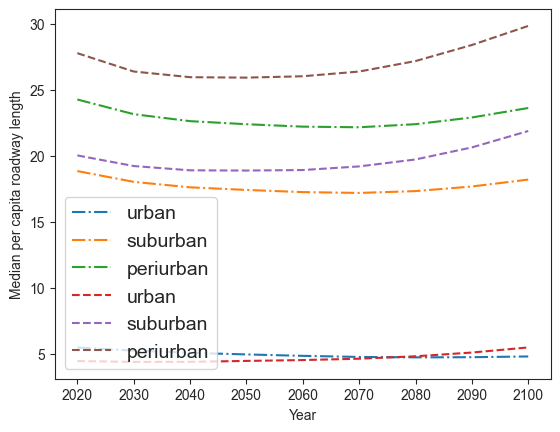

In [114]:
x = [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100] 
y1 = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y2 = roads_clean[roads_clean['city type'] == 'suburban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y3 = roads_clean[roads_clean['city type'] == 'periurban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y4 = roads_clean[roads_clean['city type'] == 'rural'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
plt.plot(x, y1, '-.', label ='urban')
plt.plot(x, y2, '-.', label ='suburban')
plt.plot(x, y3, '-.', label ='periurban')
# plt.plot(x, y4, '-.', label ='rural')

y11 = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y22 = roads_clean[roads_clean['city type'] == 'suburban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y33 = roads_clean[roads_clean['city type'] == 'periurban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y44 = roads_clean[roads_clean['city type'] == 'rural'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
plt.plot(x, y11, '--', label ='urban')
plt.plot(x, y22, '--', label ='suburban')
plt.plot(x, y33, '--', label ='periurban')
# plt.plot(x, y44, '--', label ='rural')

plt.xlabel("Year")
plt.ylabel("Median per capita roadway length")
plt.legend()
# plt.title('multiple plots')
plt.show()

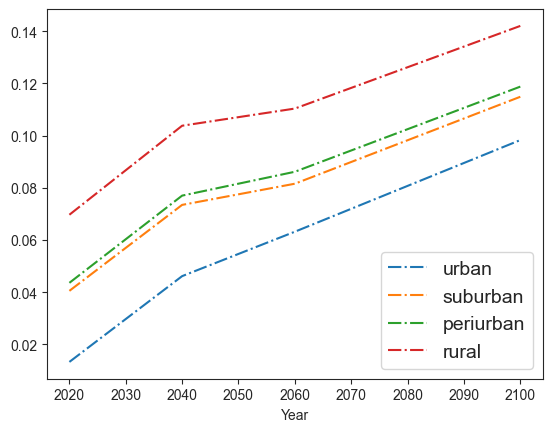

In [115]:
df_decreasing  = roads_clean[roads_clean['future trend from SSP 2'] == 'decreasing']
x = [2020,2040,2060,2100] 
y1 = df_decreasing[df_decreasing['city type'] == 'urban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y2 = df_decreasing[df_decreasing['city type'] == 'suburban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y3 = df_decreasing[df_decreasing['city type'] == 'periurban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y4 = df_decreasing[df_decreasing['city type'] == 'rural'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
plt.plot(x, y1, '-.', label ='urban')
plt.plot(x, y2, '-.', label ='suburban')
plt.plot(x, y3, '-.', label ='periurban')
plt.plot(x, y4, '-.', label ='rural')
plt.xlabel("Year")
plt.legend()
# plt.title('multiple plots')
plt.show()

In [116]:
# import plotly.express as px
# px_data = roads_clean
# fig = px.scatter(px_data, x=px_data.index, y='percent change from 2020-2040', color = 'future trend from SSP 2')
# # fig = px.scatter(px_data, x=px_data.index, y='percent change from 2060-2080', color = 'REGION')
# fig.show()

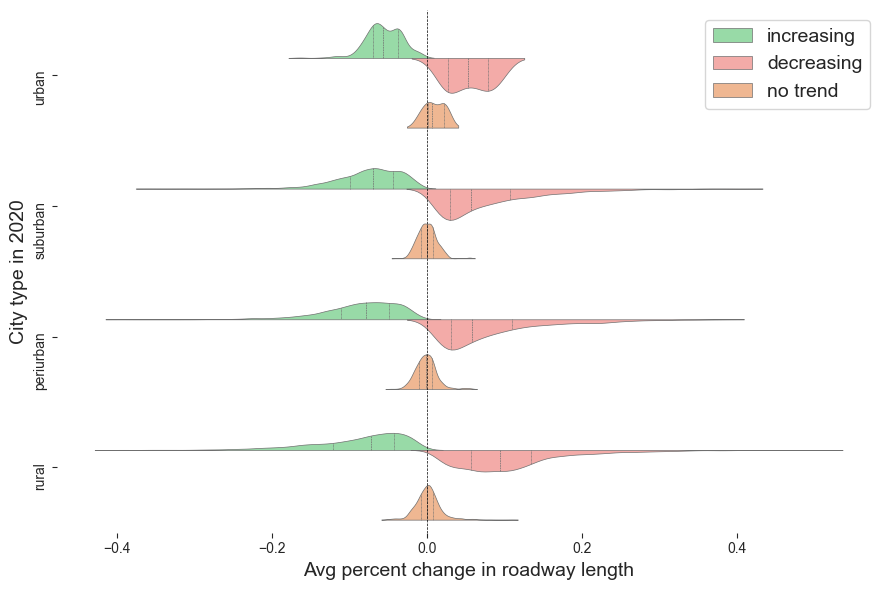

In [117]:
roads_clean['avg_percent_change'] = roads_clean[['percent change from 2020-2040', 'percent change from 2040-2060', 
                                                 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=1)
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(ax=ax, data = roads_clean, y= 'city type', x= 'avg_percent_change', hue='future trend from SSP 2', split=True, inner="quart",
               order=['urban', 'suburban', 'periurban', 'rural'], palette = ['#8de5a1','#ff9f9b', '#ffb482'], linewidth=0.5)
ax.axvline(x = 0, linestyle = '--', linewidth = 0.5, color ='black') 
ax.set(frame_on=False)
# sns.set_style("whitegrid", {'axes.grid' : False})
plt.yticks(rotation=90, ha='right')
ax.legend(fontsize=14,)
ax.set_xlabel('Avg percent change in roadway length',fontsize=14)
ax.set_ylabel('City type in 2020',fontsize=14)
sns.set_style("ticks")
fig.tight_layout()
plt.savefig(r"D:\Work\Box Sync\Quantify Infrastructure\Figures\avg_percent_roadway_change.png", transparent=True)
# plt.legend(loc='lower right')
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

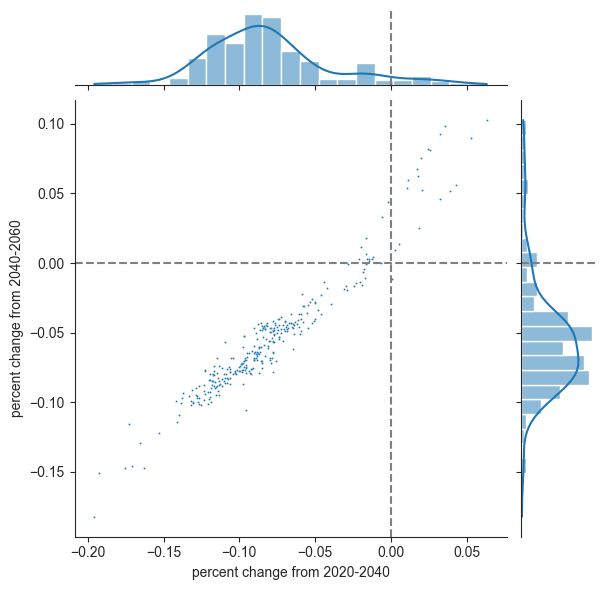

In [118]:
g = sns.JointGrid(data=roads_clean[roads_clean['city type'] == 'urban'], x='percent change from 2020-2040', y = 'percent change from 2040-2060',)
g.plot_joint(sns.scatterplot, s=2, )
g.plot_marginals(sns.histplot, kde=True)
g.refline(x=0, y=0)

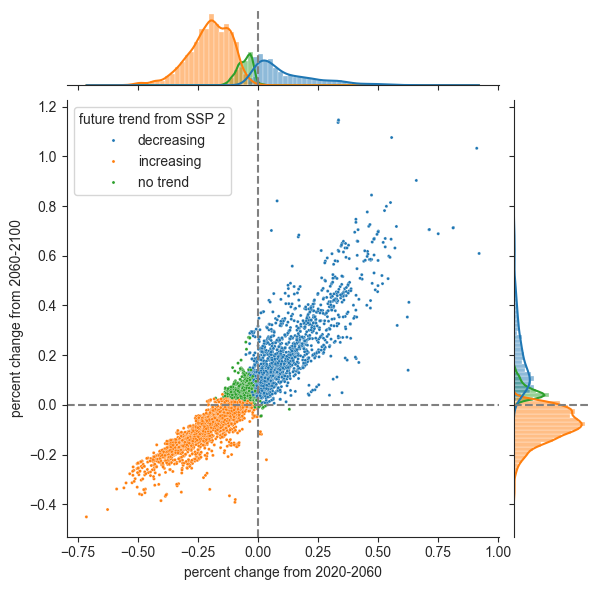

In [119]:
plt.rc('legend',fontsize=10) 
g = sns.JointGrid(data=roads_df[roads_df['city type'] == 'suburban'], x='percent change from 2020-2060', y = 'percent change from 2060-2100',
                  marginal_ticks=False, hue="future trend from SSP 2")
g.plot_joint(sns.scatterplot, s=5, )
g.plot_marginals(sns.histplot, kde=True, linewidth =0.2)
g.refline(x=0, y=0)


In [120]:
# print(sns.color_palette("pastel").as_hex())